In [5]:
import os
import json
import pandas as pd
import glob

# 🌟 你的结果根目录 (根据你的截图推断)
base_dir = "./results/criteo/train_y/TARNET"

# 5 个消融实验的目录名
versions = [
    "y_v1_base", 
    "y_v2_emb", 
    "y_v3_moe", 
    "y_v4_loss_strata", 
    "y_v5_loss_var"
]

# 🎯 我们要重点对比的指标池
metrics_to_extract = [
    "Test_Target_Y_AUUC", 
    "Valid_Target_Y_AUUC",
    # "Test_Target_Y_Lift@10", 
    # "Test_Target_Y_Lift@30",
    # "Test_Target_Y_AUC",      # 看基础分类能力有没有崩
    "Test_Target_Y_PCOC",     # 看校准度有没有飘
    "Valid_Target_C_AUUC",
    "Test_Target_C_AUUC"      # 看 C 的因果信号保留情况
]

results = []

print("🔍 正在扫描文件...")
for v in versions:
    # 巧妙使用 glob 跳过中间的 exp_name 目录，直接定位 json
    search_pattern = os.path.join(base_dir, v, "*", "final_metrics.json")
    found_files = glob.glob(search_pattern)
    
    if not found_files:
        print(f"⚠️ 找不到 {v} 的 final_metrics.json，可能还没跑完？")
        continue
        
    json_path = found_files[0]
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # 组装这一行的数据
    row = {"Version": v}
    for m in metrics_to_extract:
        val = data.get(m, None)
        # 统一保留 4 位小数，看起来清爽
        row[m] = round(val, 4) if isinstance(val, float) else val
        
    results.append(row)

# ==========================================
# 📊 打印华丽的对比战报
# ==========================================
if results:
    df = pd.DataFrame(results)
    df.set_index("Version", inplace=True)
    
    # 强制 Pandas 在终端里不折叠列
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("\n" + "="*90)
    print("🚀 Uplift 消融实验 (Stage 3) 核心指标对比战报 🚀")
    print("="*90)
    # 按顺序打印我们要看的列
    print(df[metrics_to_extract])
    print("="*90)
else:
    print("❌ 没有提取到任何数据，请检查 base_dir 路径是否正确！")

🔍 正在扫描文件...

🚀 Uplift 消融实验 (Stage 3) 核心指标对比战报 🚀
                  Test_Target_Y_AUUC  Valid_Target_Y_AUUC  Test_Target_Y_PCOC  Valid_Target_C_AUUC  Test_Target_C_AUUC
Version                                                                                                               
y_v1_base                     0.8839               0.8933              1.0158               0.7863              0.7762
y_v2_emb                      0.8723               0.8965              1.0872               0.7491              0.7451
y_v3_moe                      0.8918               0.8875              0.9808               0.8273              0.8439
y_v4_loss_strata              0.8929               0.8978              5.2689               0.7951              0.7967
y_v5_loss_var                 0.8904               0.8903             25.1867               0.7639              0.7690


In [1]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 加载 V1 和 V2 数据
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v2_path = find_csv("./results/criteo/train_y/TARNET/y_v2_emb") # 请确认你的 V2 文件夹名字

if not all([v1_path, v2_path]):
    print("❌ 找不到文件，请检查路径！")
    exit()

df_v1 = pd.read_csv(v1_path)
df_v2 = pd.read_csv(v2_path)

def generate_death_certificate(df, model_name):
    """提取判定模型生死的核心指标"""
    # 1. 序能力 (Ranking)：看 Top 10% 截断的真实提纯能力
    top_10_cutoff = int(len(df) * 0.1)
    top_10_df = df.sort_values(by='uplift_pred', ascending=False).iloc[:top_10_cutoff]
    t1, t0 = top_10_df[top_10_df['t']==1], top_10_df[top_10_df['t']==0]
    real_uplift_top10 = t1['y_true'].mean() - t0['y_true'].mean() if len(t1)>0 and len(t0)>0 else 0
    
    # 2. 值中枢 (Calibration)：看模型整体预估值的均值，偏离真实大盘有多远
    mean_pred = df['uplift_pred'].mean()
    
    t1_all, t0_all = df[df['t']==1], df[df['t']==0]
    mean_real = t1_all['y_true'].mean() - t0_all['y_true'].mean()
    
    # 3. 业务死穴 (Business Viability)：预估值 <= 0 的比例
    # 如果一个模型的输出全是负数，在真实业务中就没法通过阈值（>0）来发券
    negative_ratio = (df['uplift_pred'] <= 0).mean() * 100
    
    return {
        'Model': model_name,
        'Top_10%_Real_Y (排序幸存度)': real_uplift_top10,
        'Mean_Pred (预估均值)': mean_pred,
        'Global_Real (大盘真理)': mean_real,
        'Negative_Ratio (发券拒止率)': f"{negative_ratio:.2f}%"
    }

res_df = pd.DataFrame([
    generate_death_certificate(df_v1, "V1 (纯 Y 塔)"),
    generate_death_certificate(df_v2, "V2 (Emb 早期拼接)")
]).set_index('Model')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.6f}'.format)

print("\n" + "="*120)
print("💀 [V2 死亡证明] Early Fusion 架构的『数值坍塌』与『排序幸存』判定")
print("="*120)
print(res_df)
print("="*120)


💀 [V2 死亡证明] Early Fusion 架构的『数值坍塌』与『排序幸存』判定
               Top_10%_Real_Y (排序幸存度)  Mean_Pred (预估均值)  Global_Real (大盘真理) Negative_Ratio (发券拒止率)
Model                                                                                             
V1 (纯 Y 塔)                   0.008623          0.000668            0.001153                 81.98%
V2 (Emb 早期拼接)                0.007657         -0.004067            0.001153                 99.95%


In [3]:
import os
import json
import pandas as pd
import glob

base_dir = "./results/criteo/train_y/TARNET"
versions = ["y_v1_base", "y_v2_emb", "y_v3_moe", "y_v4_loss_strata", "y_v5_loss_var"]

metrics_to_extract = [
    "Test_Target_Y_AUUC", 
    "Test_Target_Y_AUC",      # 异常点 1: < 0.5 说明预测完全反转
    "Test_Target_Y_PCOC",     # 异常点 2: 偏离 1.0 说明极度高估/低估
    "Test_Target_Y_MAE",      # 异常点 3: 绝对误差，越小越好
    "Test_Target_Y_Lift@10", 
]

results = []
for v in versions:
    search_pattern = os.path.join(base_dir, v, "*", "final_metrics.json")
    found_files = glob.glob(search_pattern)
    if not found_files: continue
    with open(found_files[0], 'r') as f: data = json.load(f)
    row = {"Version": v}
    for m in metrics_to_extract:
        val = data.get(m, None)
        row[m] = round(val, 4) if isinstance(val, float) else val
    results.append(row)

if results:
    df = pd.DataFrame(results).set_index("Version")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print("\n" + "="*90)
    print("🚀 Uplift 消融实验 (Stage 3) - 异常诊断战报 🚀")
    print("="*90)
    print(df[metrics_to_extract])
    print("="*90)


🚀 Uplift 消融实验 (Stage 3) - 异常诊断战报 🚀
                  Test_Target_Y_AUUC  Test_Target_Y_AUC  Test_Target_Y_PCOC  Test_Target_Y_MAE  Test_Target_Y_Lift@10
Version                                                                                                              
y_v1_base                     0.8839             0.9210              1.0158             0.0056                 0.0086
y_v2_emb                      0.8723             0.1610              1.0872             0.0061                 0.0077
y_v3_moe                      0.8918             0.9386              0.9808             0.0051                 0.0082
y_v4_loss_strata              0.8929             0.8524              5.2689             0.0180                 0.0083
y_v5_loss_var                 0.8904             0.0933             25.1867             0.0763                 0.0079


In [4]:
import os
import glob
import pandas as pd
import numpy as np

base_dir = "./results/criteo/train_y/TARNET"
versions = ["y_v1_base", "y_v2_emb", "y_v3_moe", "y_v4_loss_strata", "y_v5_loss_var"]

results = []

print("🔍 正在扫描 test_dist.csv 并分析预测分布...")
for v in versions:
    # 自动寻找 test_dist.csv
    search_pattern = os.path.join(base_dir, v, "*", "test_dist.csv")
    found_files = glob.glob(search_pattern)
    
    if not found_files:
        continue
        
    csv_path = found_files[0]
    df = pd.read_csv(csv_path)
    
    # 提取真实大盘转化率
    true_ctr = df['y_true'].mean()
    
    # 分析预测的分布特征
    y0_mean = df['y0_prob'].mean()
    y1_mean = df['y1_prob'].mean()
    uplift_mean = df['uplift_pred'].mean()
    uplift_std = df['uplift_pred'].std()  # 看模型有没有塌缩成只预测同一个值
    
    y1_max = df['y1_prob'].max()
    y1_min = df['y1_prob'].min()

    results.append({
        "Version": v,
        "True_CTR": round(true_ctr, 4),
        "Pred_y0_Mean": round(y0_mean, 4),
        "Pred_y1_Mean": round(y1_mean, 4),
        "y1_Min": round(y1_min, 4),
        "y1_Max": round(y1_max, 4),
        "Uplift_Mean": round(uplift_mean, 5),
        "Uplift_Std (波动)": round(uplift_std, 5)
    })

if results:
    dist_df = pd.DataFrame(results).set_index("Version")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("\n" + "="*100)
    print("🏥 预测概率分布深度体检报告 (查杀 PCOC 爆炸与 AUC 反转元凶)")
    print("="*100)
    print(dist_df)
    print("="*100)
    print("\n💡 诊断指南：")
    print("1. Pred_y1_Mean 如果远大于 True_CTR (比如 0.99 vs 0.05)，说明模型放飞自我，全猜正样本。")
    print("2. Uplift_Std 趋近于 0，说明双塔输出完全一样，模型塌缩了，失去了给用户排序的能力。")
    print("3. y1_Max 如果全是 1.0，y1_Min 全是 0.0，极有可能是 Logits 没有做 Sigmoid 导致的梯度爆炸！")
else:
    print("❌ 没有找到 test_dist.csv 文件！")

🔍 正在扫描 test_dist.csv 并分析预测分布...

🏥 预测概率分布深度体检报告 (查杀 PCOC 爆炸与 AUC 反转元凶)
                  True_CTR  Pred_y0_Mean  Pred_y1_Mean  y1_Min  y1_Max  Uplift_Mean  Uplift_Std (波动)
Version                                                                                             
y_v1_base           0.0029        0.0024        0.0030  0.0000  0.3041      0.00067          0.00360
y_v2_emb            0.0029        0.0066        0.0026  0.0002  0.0106     -0.00407          0.00113
y_v3_moe            0.0029        0.0021        0.0030  0.0001  0.7571      0.00084          0.00412
y_v4_loss_strata    0.0029        0.0137        0.0156  0.0020  0.2057      0.00193          0.00543
y_v5_loss_var       0.0029        0.0957        0.0696  0.0004  0.1133     -0.02611          0.00616

💡 诊断指南：
1. Pred_y1_Mean 如果远大于 True_CTR (比如 0.99 vs 0.05)，说明模型放飞自我，全猜正样本。
2. Uplift_Std 趋近于 0，说明双塔输出完全一样，模型塌缩了，失去了给用户排序的能力。
3. y1_Max 如果全是 1.0，y1_Min 全是 0.0，极有可能是 Logits 没有做 Sigmoid 导致的梯度爆炸！


📄 正在读取 Model C 数据: ./results/criteo/train_c/TARNET/c_v1_base/exp_c_explore/test_dist.csv

✅ Model C 可视化完成！图片已保存至: model_c_vigintile_analysis.png


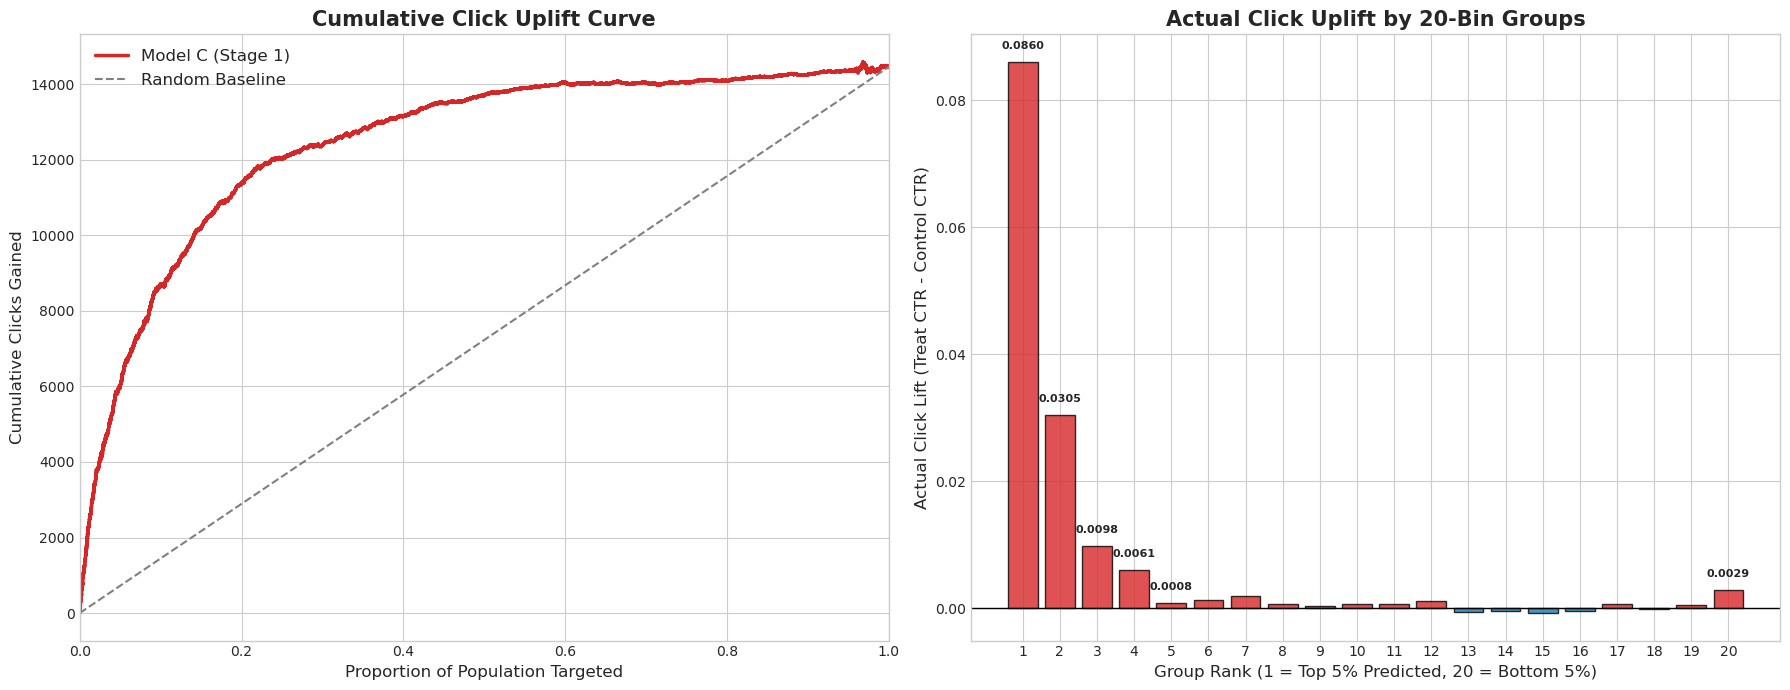

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 自动定位 Model C 的 test_dist.csv
# ==========================================
# 路径指向 train_c (点击增益阶段)
base_dir = "./results/criteo/train_c/TARNET/c_v1_base"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print(f"❌ 找不到 Model C 的 test_dist.csv，请检查路径: {base_dir}")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取 Model C 数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列 (注意：Stage 1 通常是 c_true 代表点击)
# 如果你的列名依然是 y_true，请将此处改为 'y_true'
label_col = 'c_true' if 'c_true' in df.columns else 'y_true'
c_true = df[label_col].values
t = df['t'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列
order = np.argsort(uplift_pred)[::-1]
c_true_sorted = c_true[order]
t_sorted = t[order]

# ==========================================
# 📊 计算 Uplift 曲线数据 (Cumulative)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(c_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(c_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 标准 Uplift 曲线公式: (Treat_CTR - Control_CTR) * 累计人数
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(c_true) + 1) / len(c_true)

# 计算 Random Baseline
random_curve = x_axis * uplift_curve[-1]

# ==========================================
# 📊 计算 20 个桶 (Vigintiles) 柱状图数据
# ==========================================
num_bins = 20
bin_size = len(c_true) // num_bins
bin_uplifts = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(c_true)
    
    bin_y = c_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    # 计算当前桶内的实际增益
    ctr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    ctr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    bin_uplifts.append(ctr_t - ctr_c)

# ==========================================
# 🎨 绘图：Model C 深度校准图
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 图 1: Cumulative Uplift Curve
ax1.plot(x_axis, uplift_curve, label='Model C (Stage 1)', color='#d62728', linewidth=2.5)
ax1.plot(x_axis, random_curve, label='Random Baseline', color='gray', linestyle='--')
ax1.set_title('Cumulative Click Uplift Curve', fontsize=15, fontweight='bold')
ax1.set_xlabel('Proportion of Population Targeted', fontsize=12)
ax1.set_ylabel('Cumulative Clicks Gained', fontsize=12)
ax1.legend(fontsize=12)
ax1.set_xlim([0, 1.0])

# 图 2: 20-Bin Actual Uplift Bar Chart
x_bars = np.arange(1, 21)
# 颜色映射：正值深红，负值蓝色（或者反过来，看你偏好，这里用红色系对应 Model C）
colors = ['#d62728' if val > 0 else '#1f77b4' for val in bin_uplifts]
ax2.bar(x_bars, bin_uplifts, color=colors, alpha=0.8, edgecolor='black', width=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Actual Click Uplift by 20-Bin Groups', fontsize=15, fontweight='bold')
ax2.set_xlabel('Group Rank (1 = Top 5% Predicted, 20 = Bottom 5%)', fontsize=12)
ax2.set_ylabel('Actual Click Lift (Treat CTR - Control CTR)', fontsize=12)
ax2.set_xticks(x_bars)

# 针对 20 个桶，标签缩小一点，只标前几个和关键点
for i, v in enumerate(bin_uplifts):
    if i < 5 or i == 19 or abs(v) > np.max(np.abs(bin_uplifts))*0.5:
        ax2.text(i + 1, v + (max(bin_uplifts)*0.02 if v > 0 else -max(bin_uplifts)*0.05), 
                 f"{v:.4f}", ha='center', va='bottom' if v > 0 else 'top', fontsize=8, fontweight='bold')

plt.tight_layout()
save_path = "model_c_vigintile_analysis.png"
plt.savefig(save_path, dpi=300)
print(f"\n✅ Model C 可视化完成！图片已保存至: {save_path}")
plt.show()

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v1_base/run_v1_base/test_dist.csv

🎉 V1 Baseline 20 桶可视化完成！图片已保存至: v1_baseline_20bin_analysis.png


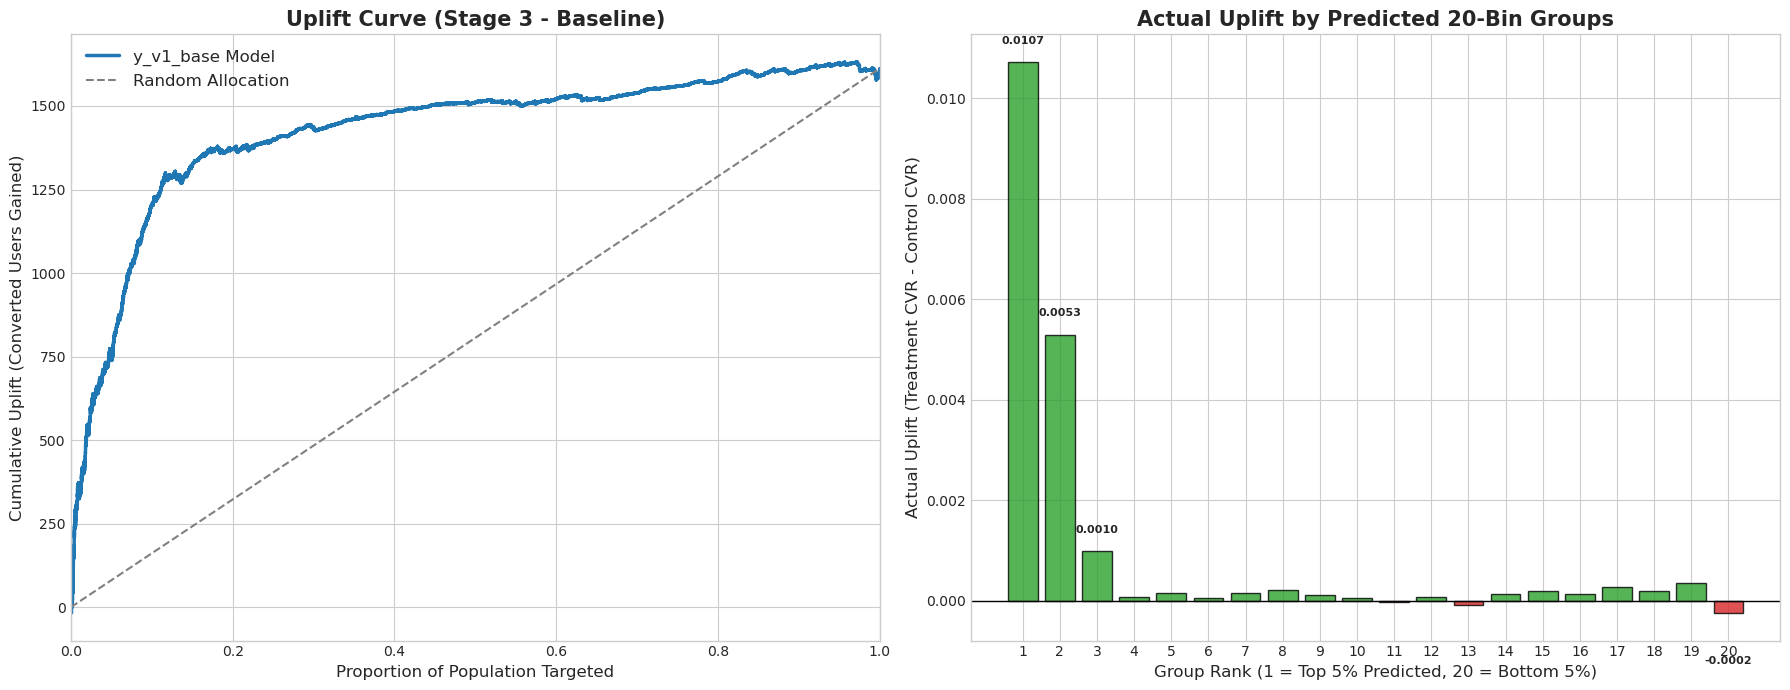

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 自动定位 V1 Baseline 的 test_dist.csv
# ==========================================
base_dir = "./results/criteo/train_y/TARNET/y_v1_base"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print(f"❌ 找不到 V1 的 test_dist.csv，请检查路径: {base_dir}")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 计算 Uplift 曲线数据 (Cumulative)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 标准 Uplift 曲线公式
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)

# 计算 Random Baseline
total_uplift = uplift_curve[-1]
random_curve = x_axis * total_uplift

# ==========================================
# 📊 计算 20 个桶 (Vigintiles) 柱状图数据
# ==========================================
num_bins = 20  # 🚀 已修改为 20 桶
bin_size = len(y_true) // num_bins
bin_uplifts = []

for i in range(num_bins):
    start_idx = i * bin_size
    # 最后一个 bin 处理余数
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    # 计算当前桶内的实际转化增益
    # 公式: Treat_CVR - Control_CVR
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    bin_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 绘图：V1 Baseline 深度分析图 (20 Bins)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 图 1: Cumulative Uplift Curve
ax1.plot(x_axis, uplift_curve, label='y_v1_base Model', color='#1f77b4', linewidth=2.5)
ax1.plot(x_axis, random_curve, label='Random Allocation', color='gray', linestyle='--')
ax1.set_title('Uplift Curve (Stage 3 - Baseline)', fontsize=15, fontweight='bold')
ax1.set_xlabel('Proportion of Population Targeted', fontsize=12)
ax1.set_ylabel('Cumulative Uplift (Converted Users Gained)', fontsize=12)
ax1.legend(fontsize=12, loc='upper left')
ax1.set_xlim([0, 1.0])

# 图 2: 20-Bin Actual Uplift Bar Chart
x_bars = np.arange(1, 21)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in bin_uplifts] # 正绿负红
ax2.bar(x_bars, bin_uplifts, color=colors, alpha=0.8, edgecolor='black', width=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Actual Uplift by Predicted 20-Bin Groups', fontsize=15, fontweight='bold')
ax2.set_xlabel('Group Rank (1 = Top 5% Predicted, 20 = Bottom 5%)', fontsize=12)
ax2.set_ylabel('Actual Uplift (Treatment CVR - Control CVR)', fontsize=12)
ax2.set_xticks(x_bars)

# 添加数值标签 (为了美观，只给显著或两端的柱子标数值)
for i, v in enumerate(bin_uplifts):
    # 只标前 3 个、最后一个，以及显著的正负值
    if i < 3 or i == 19 or abs(v) > np.max(np.abs(bin_uplifts)) * 0.4:
        ax2.text(i + 1, v + (max(bin_uplifts)*0.03 if v > 0 else -max(bin_uplifts)*0.08), 
                 f"{v:.4f}", ha='center', va='bottom' if v > 0 else 'top', 
                 fontsize=8, fontweight='bold')

plt.tight_layout()
save_path = "v1_baseline_20bin_analysis.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 V1 Baseline 20 桶可视化完成！图片已保存至: {save_path}")
plt.show()

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v1_base/run_v1_base/test_dist.csv

🎉 画图完成！图片已保存至当前目录的: v1_baseline_analysis.png


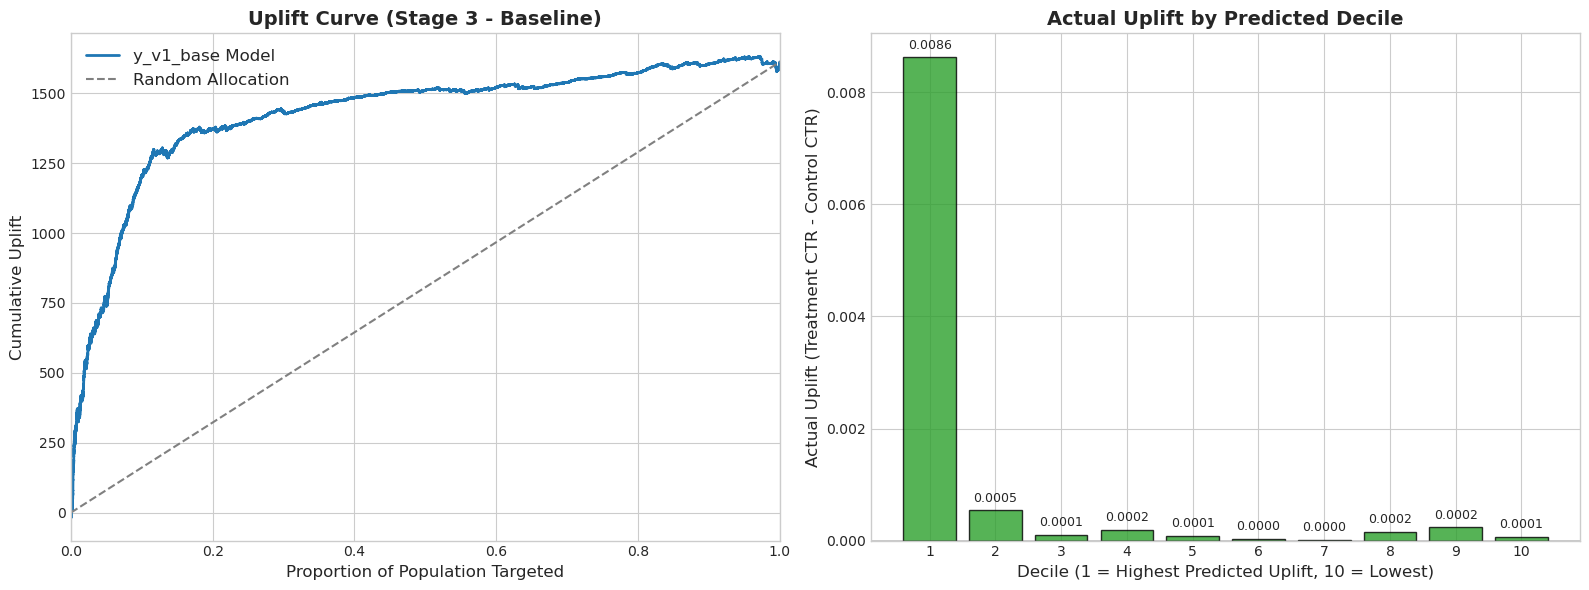

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v1_base"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 计算 Uplift 曲线数据
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 标准 Uplift 曲线公式
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)

# 计算 Random Baseline (终点相连的直线)
total_uplift = uplift_curve[-1]
random_curve = x_axis * total_uplift

# ==========================================
# 📊 计算十分位 (Decile) 柱状图数据
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []

for i in range(num_bins):
    start_idx = i * bin_size
    # 最后一个 bin 把剩下的全包进去
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 开始画图
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid') # 干净的学术风
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 图 1: Uplift Curve
ax1.plot(x_axis, uplift_curve, label='y_v1_base Model', color='#1f77b4', linewidth=2)
ax1.plot(x_axis, random_curve, label='Random Allocation', color='gray', linestyle='--')
ax1.set_title('Uplift Curve (Stage 3 - Baseline)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Proportion of Population Targeted', fontsize=12)
ax1.set_ylabel('Cumulative Uplift', fontsize=12)
ax1.legend(fontsize=12)
ax1.set_xlim([0, 1.0])

# 图 2: Decile Bar Chart
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts] # 正收益绿色，负收益红色
ax2.bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Actual Uplift by Predicted Decile', fontsize=14, fontweight='bold')
ax2.set_xlabel('Decile (1 = Highest Predicted Uplift, 10 = Lowest)', fontsize=12)
ax2.set_ylabel('Actual Uplift (Treatment CTR - Control CTR)', fontsize=12)
ax2.set_xticks(x_bars)

# 添加数值标签
for i, v in enumerate(decile_uplifts):
    ax2.text(i + 1, v + (0.0001 if v > 0 else -0.0003), f"{v:.4f}", 
             ha='center', va='bottom' if v > 0 else 'top', fontsize=9)

plt.tight_layout()
save_path = "v1_baseline_analysis.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 画图完成！图片已保存至当前目录的: {save_path}")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v1_base/run_v1_base/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v1_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


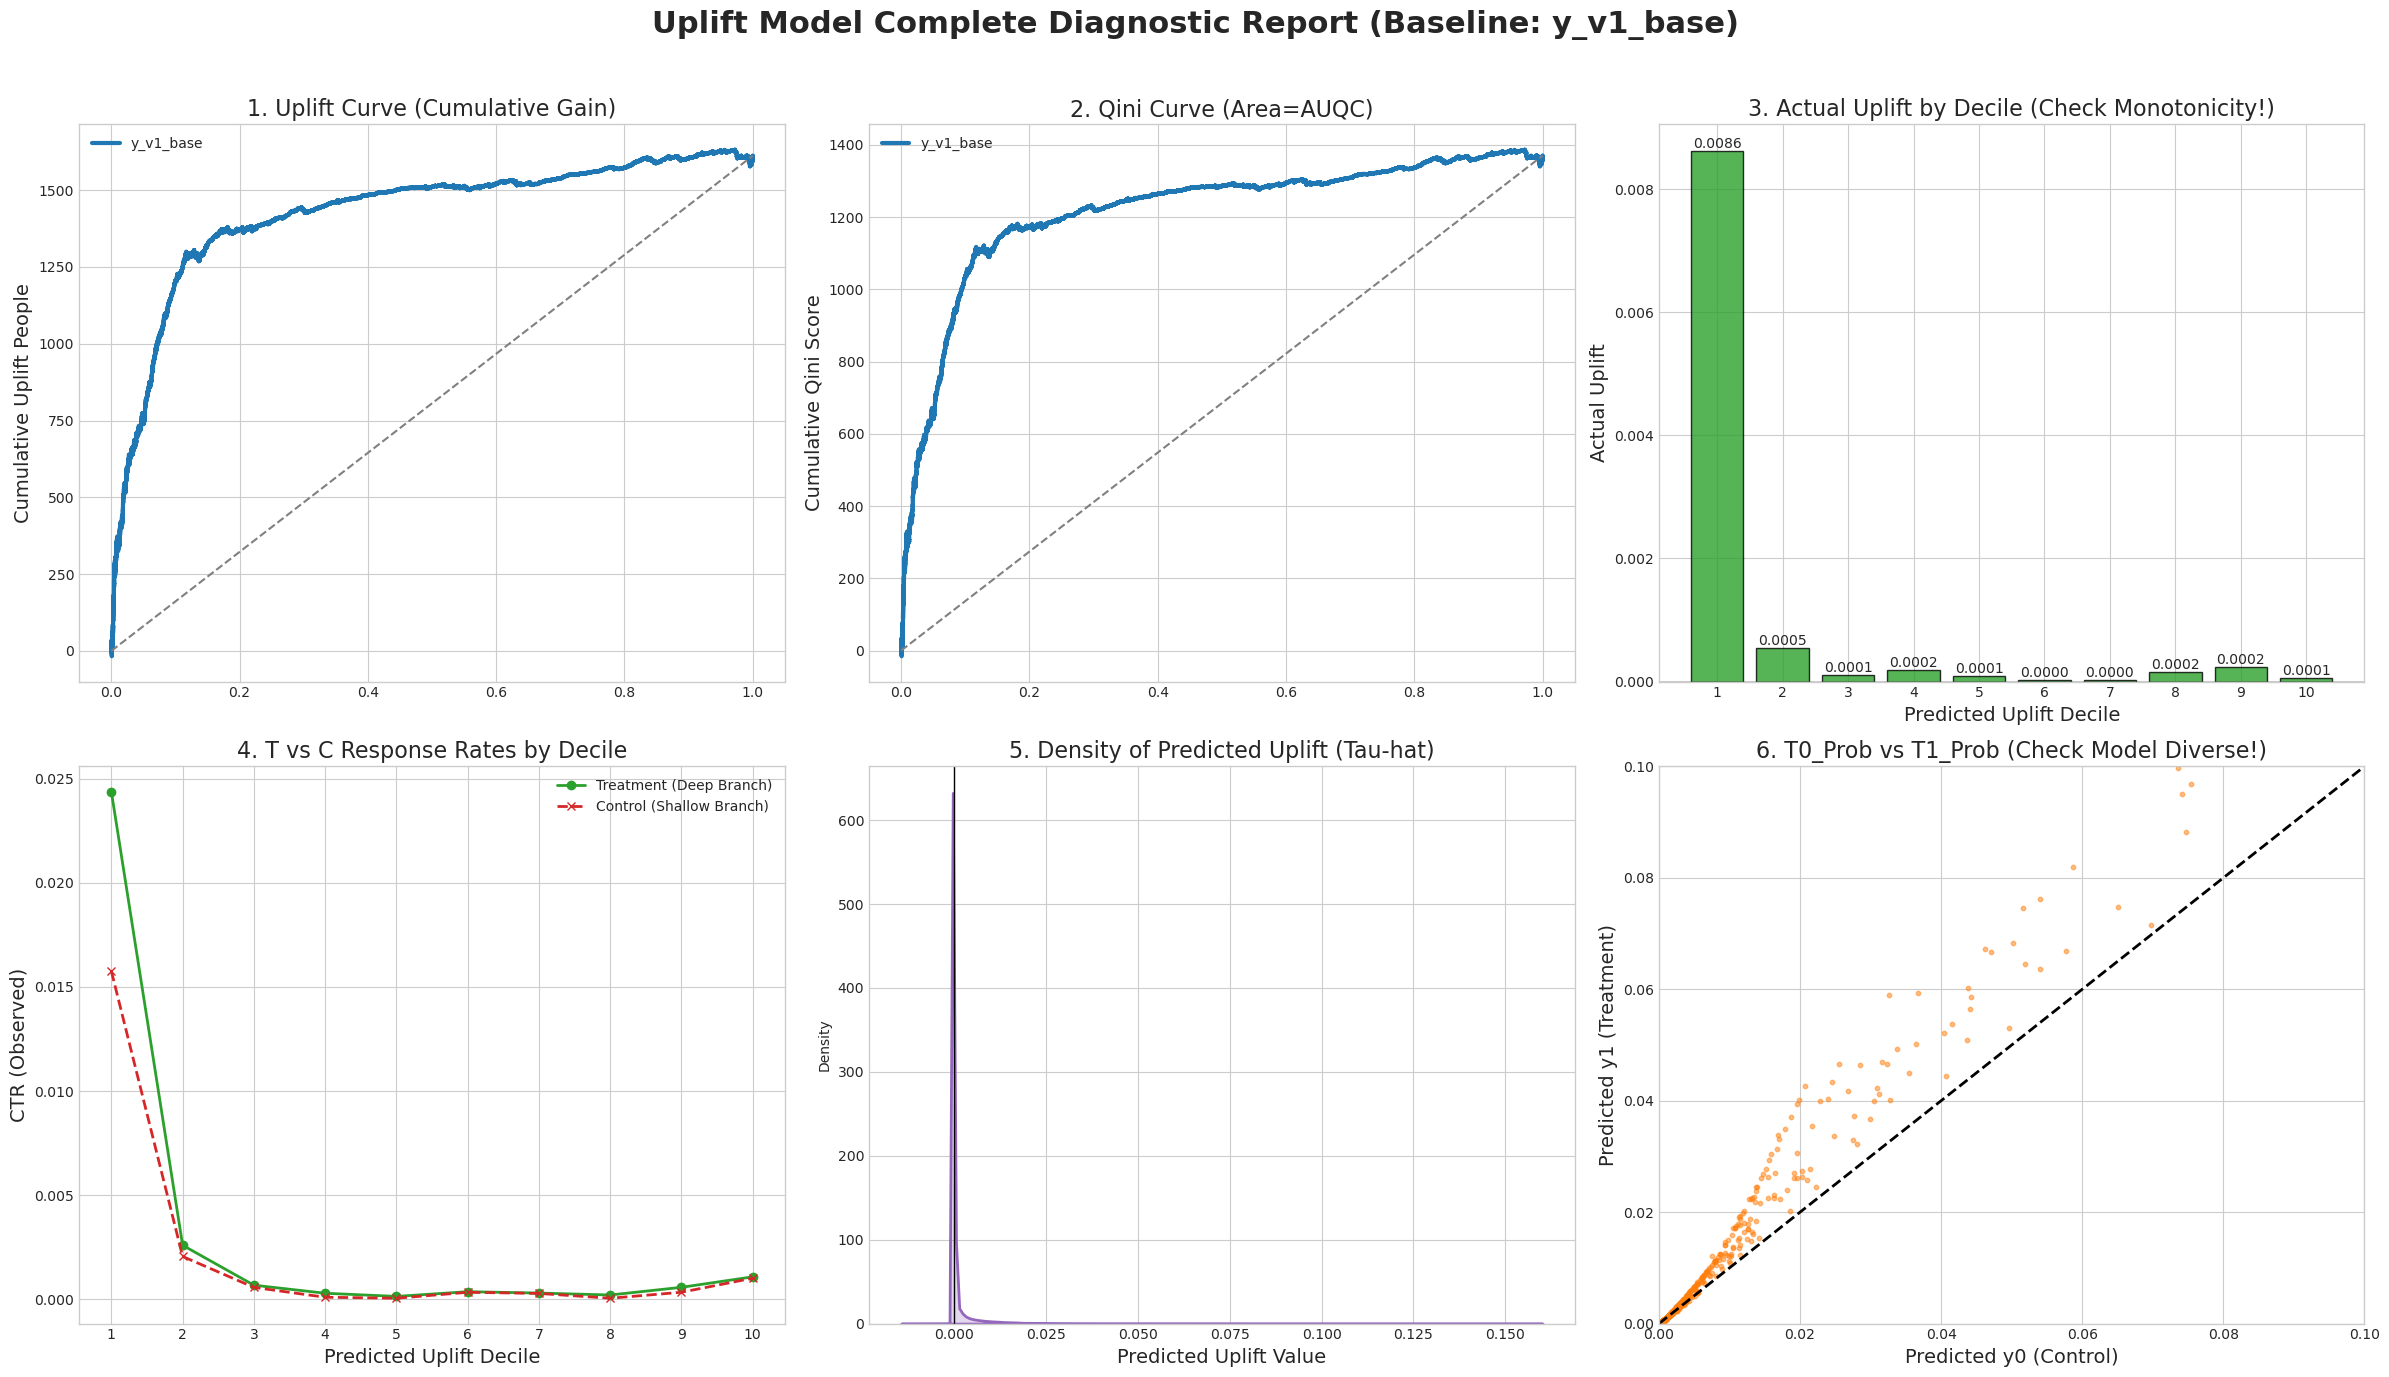

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v1_base"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v1_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v2_emb/run_v2_emb/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v2_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


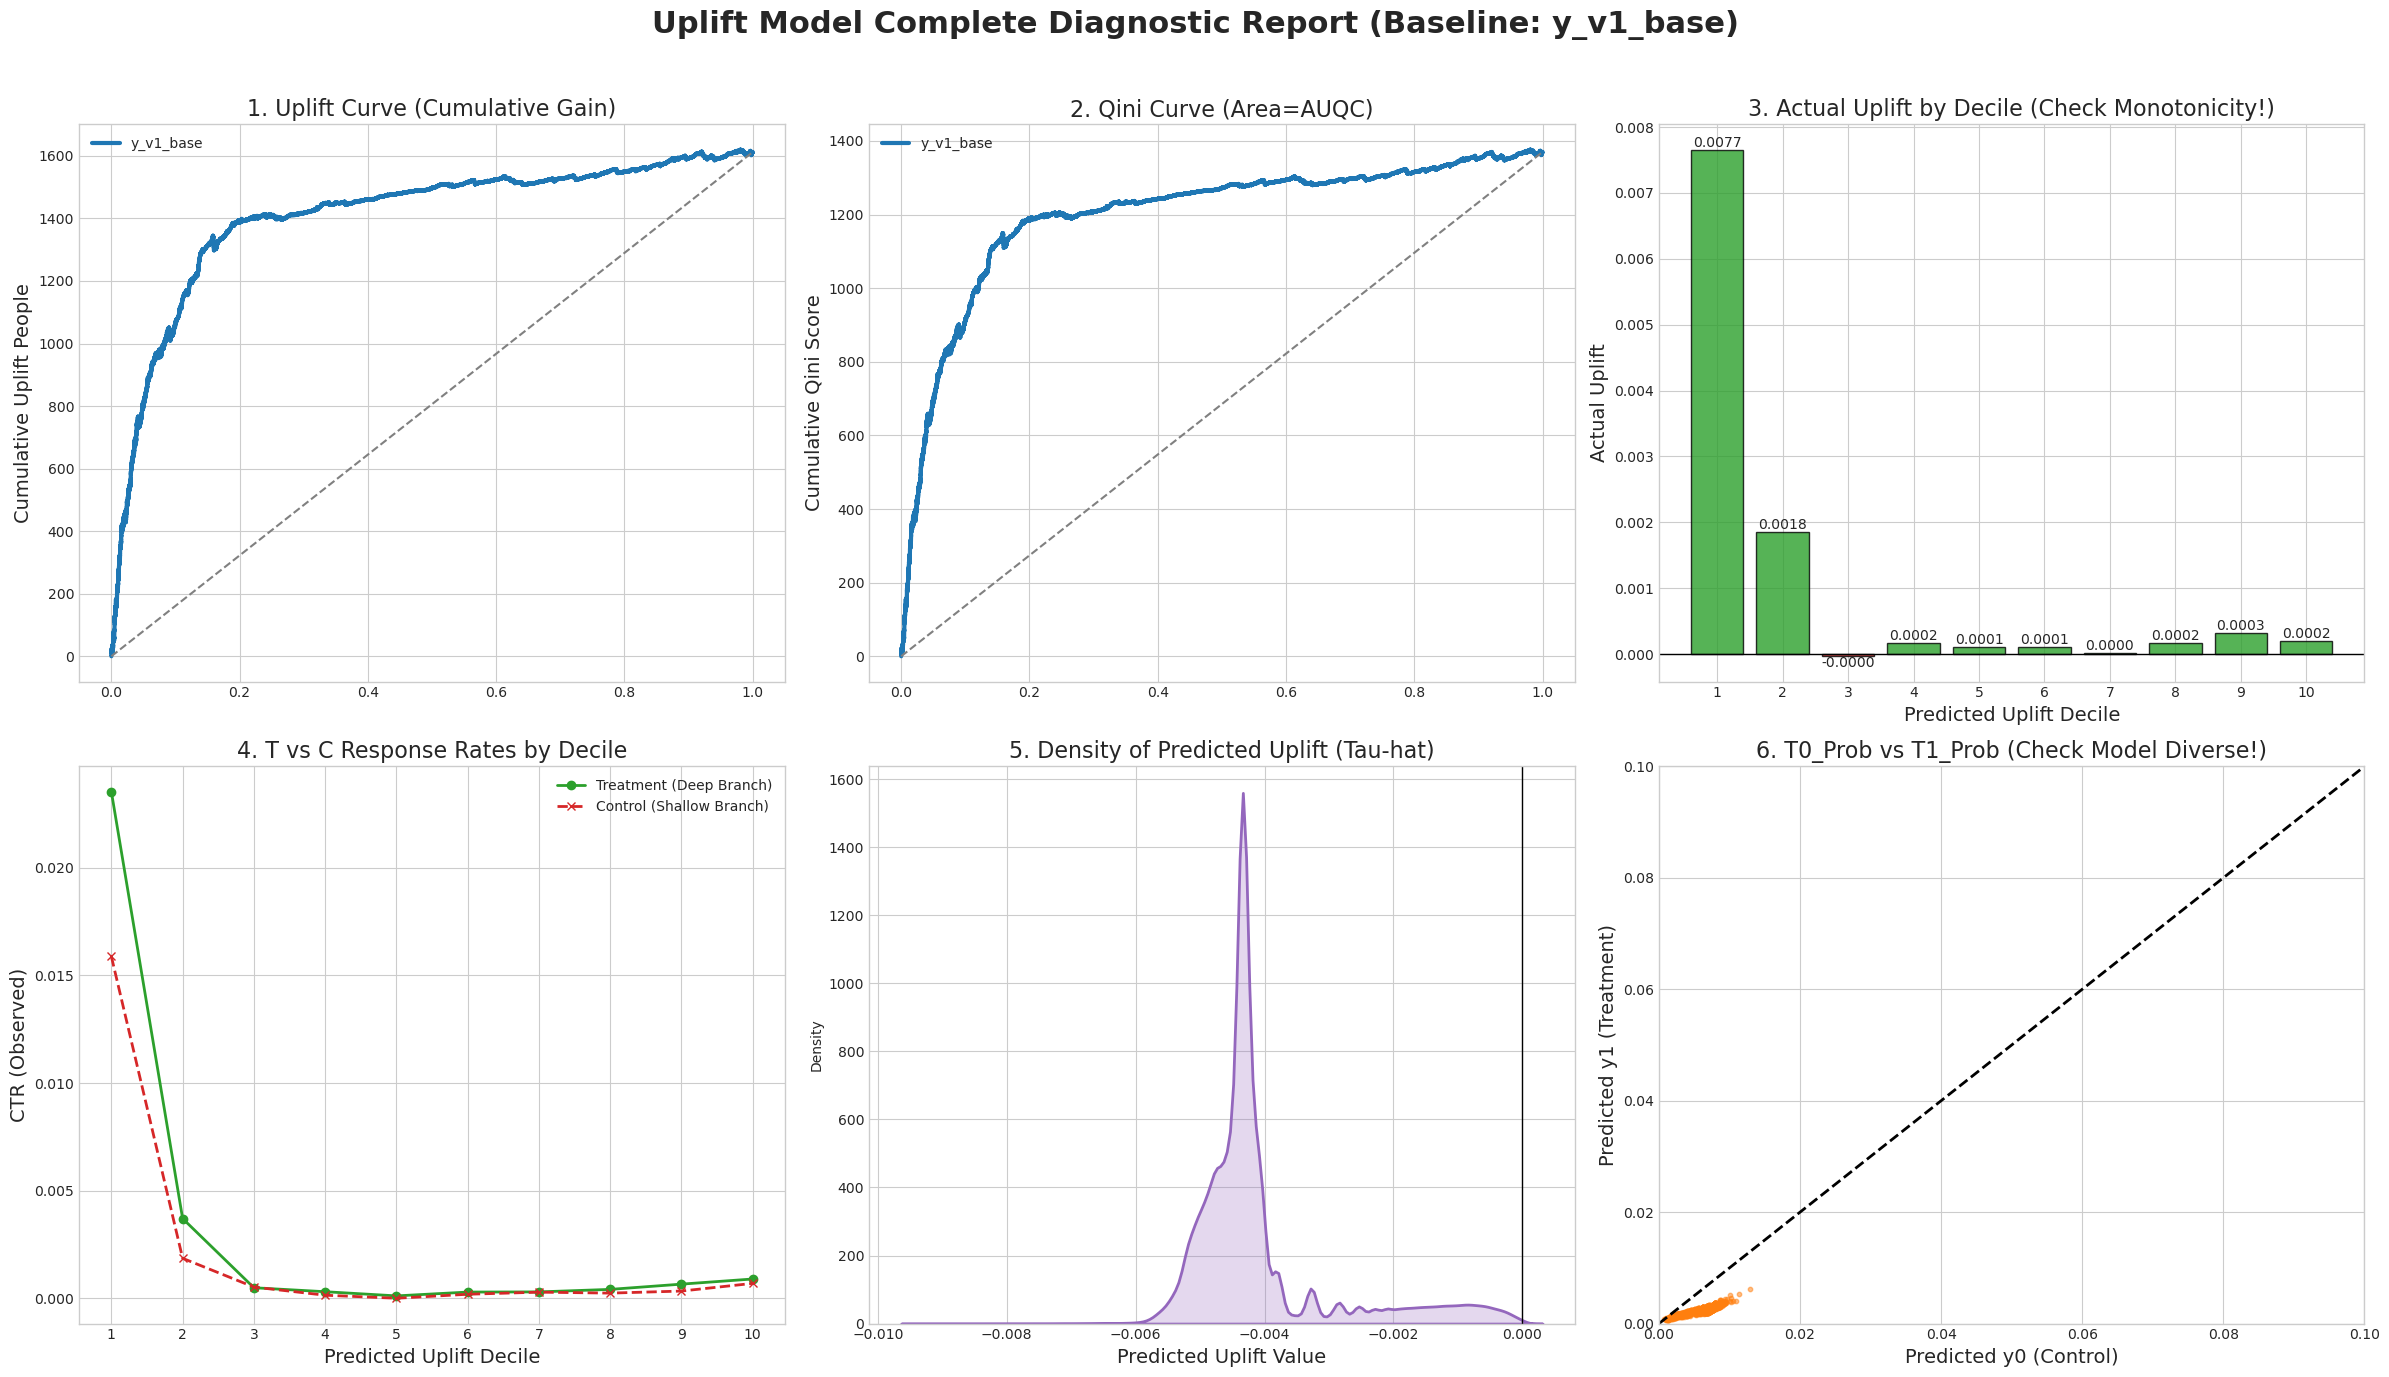

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v2_emb"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v2_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v3_moe/run_v3_moe/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v3_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


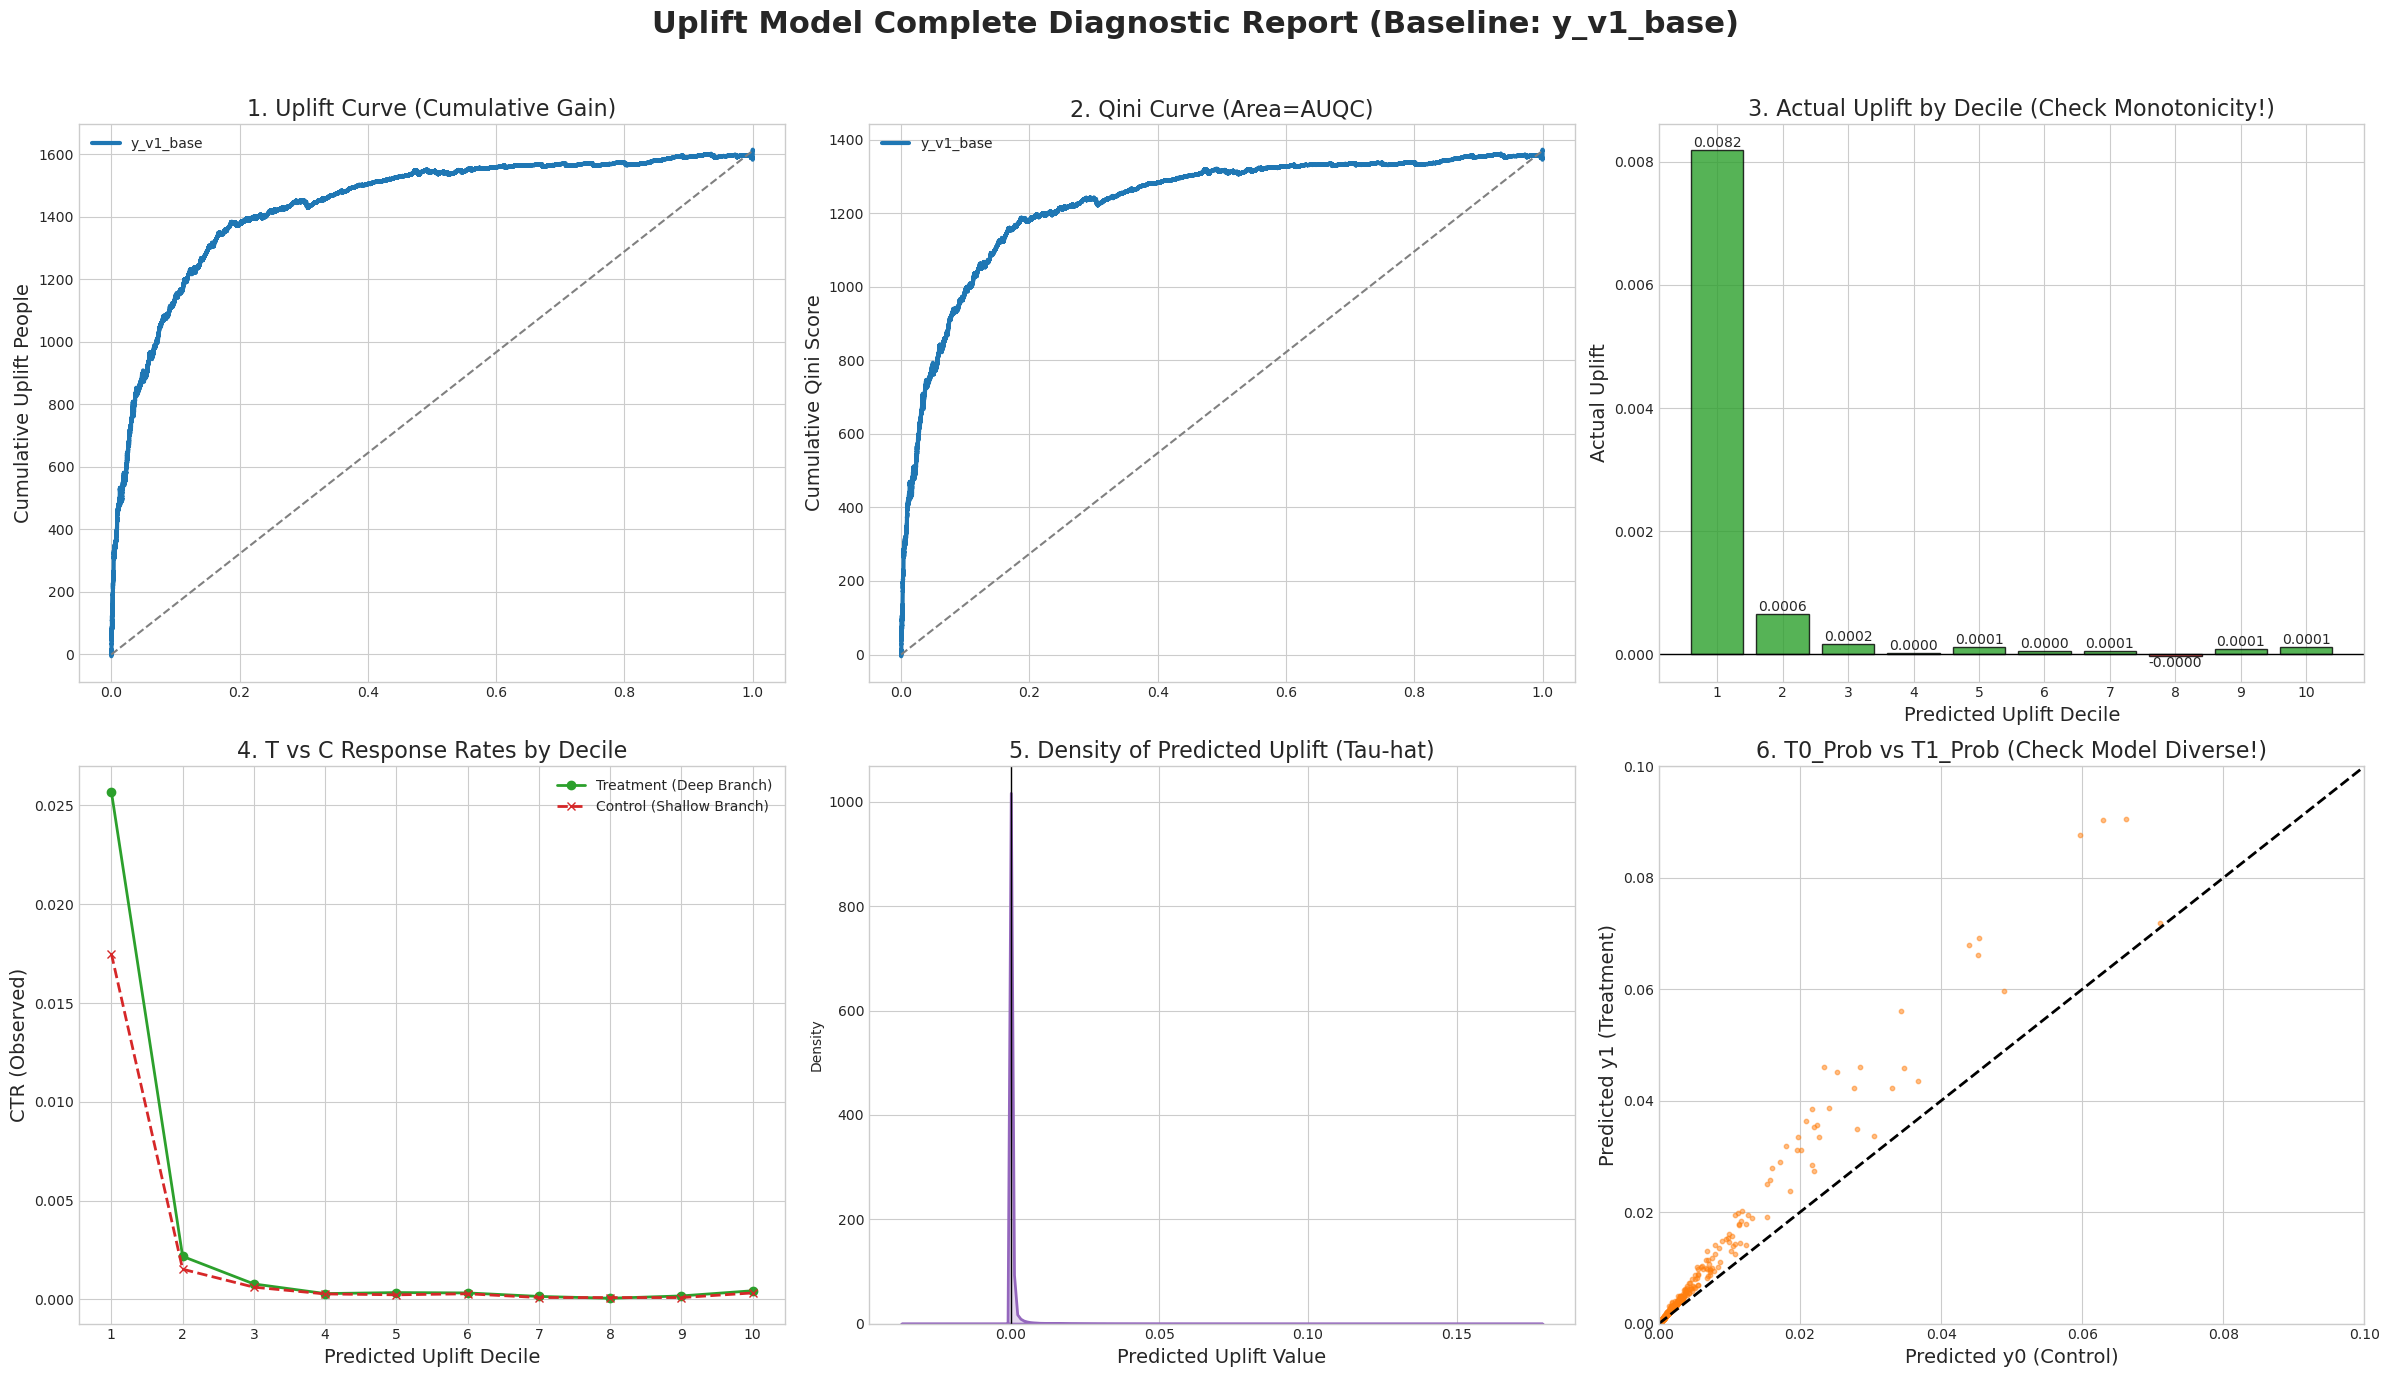

In [9]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v3_moe"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v3_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v4_loss_strata/run_v4_strata/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v4_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


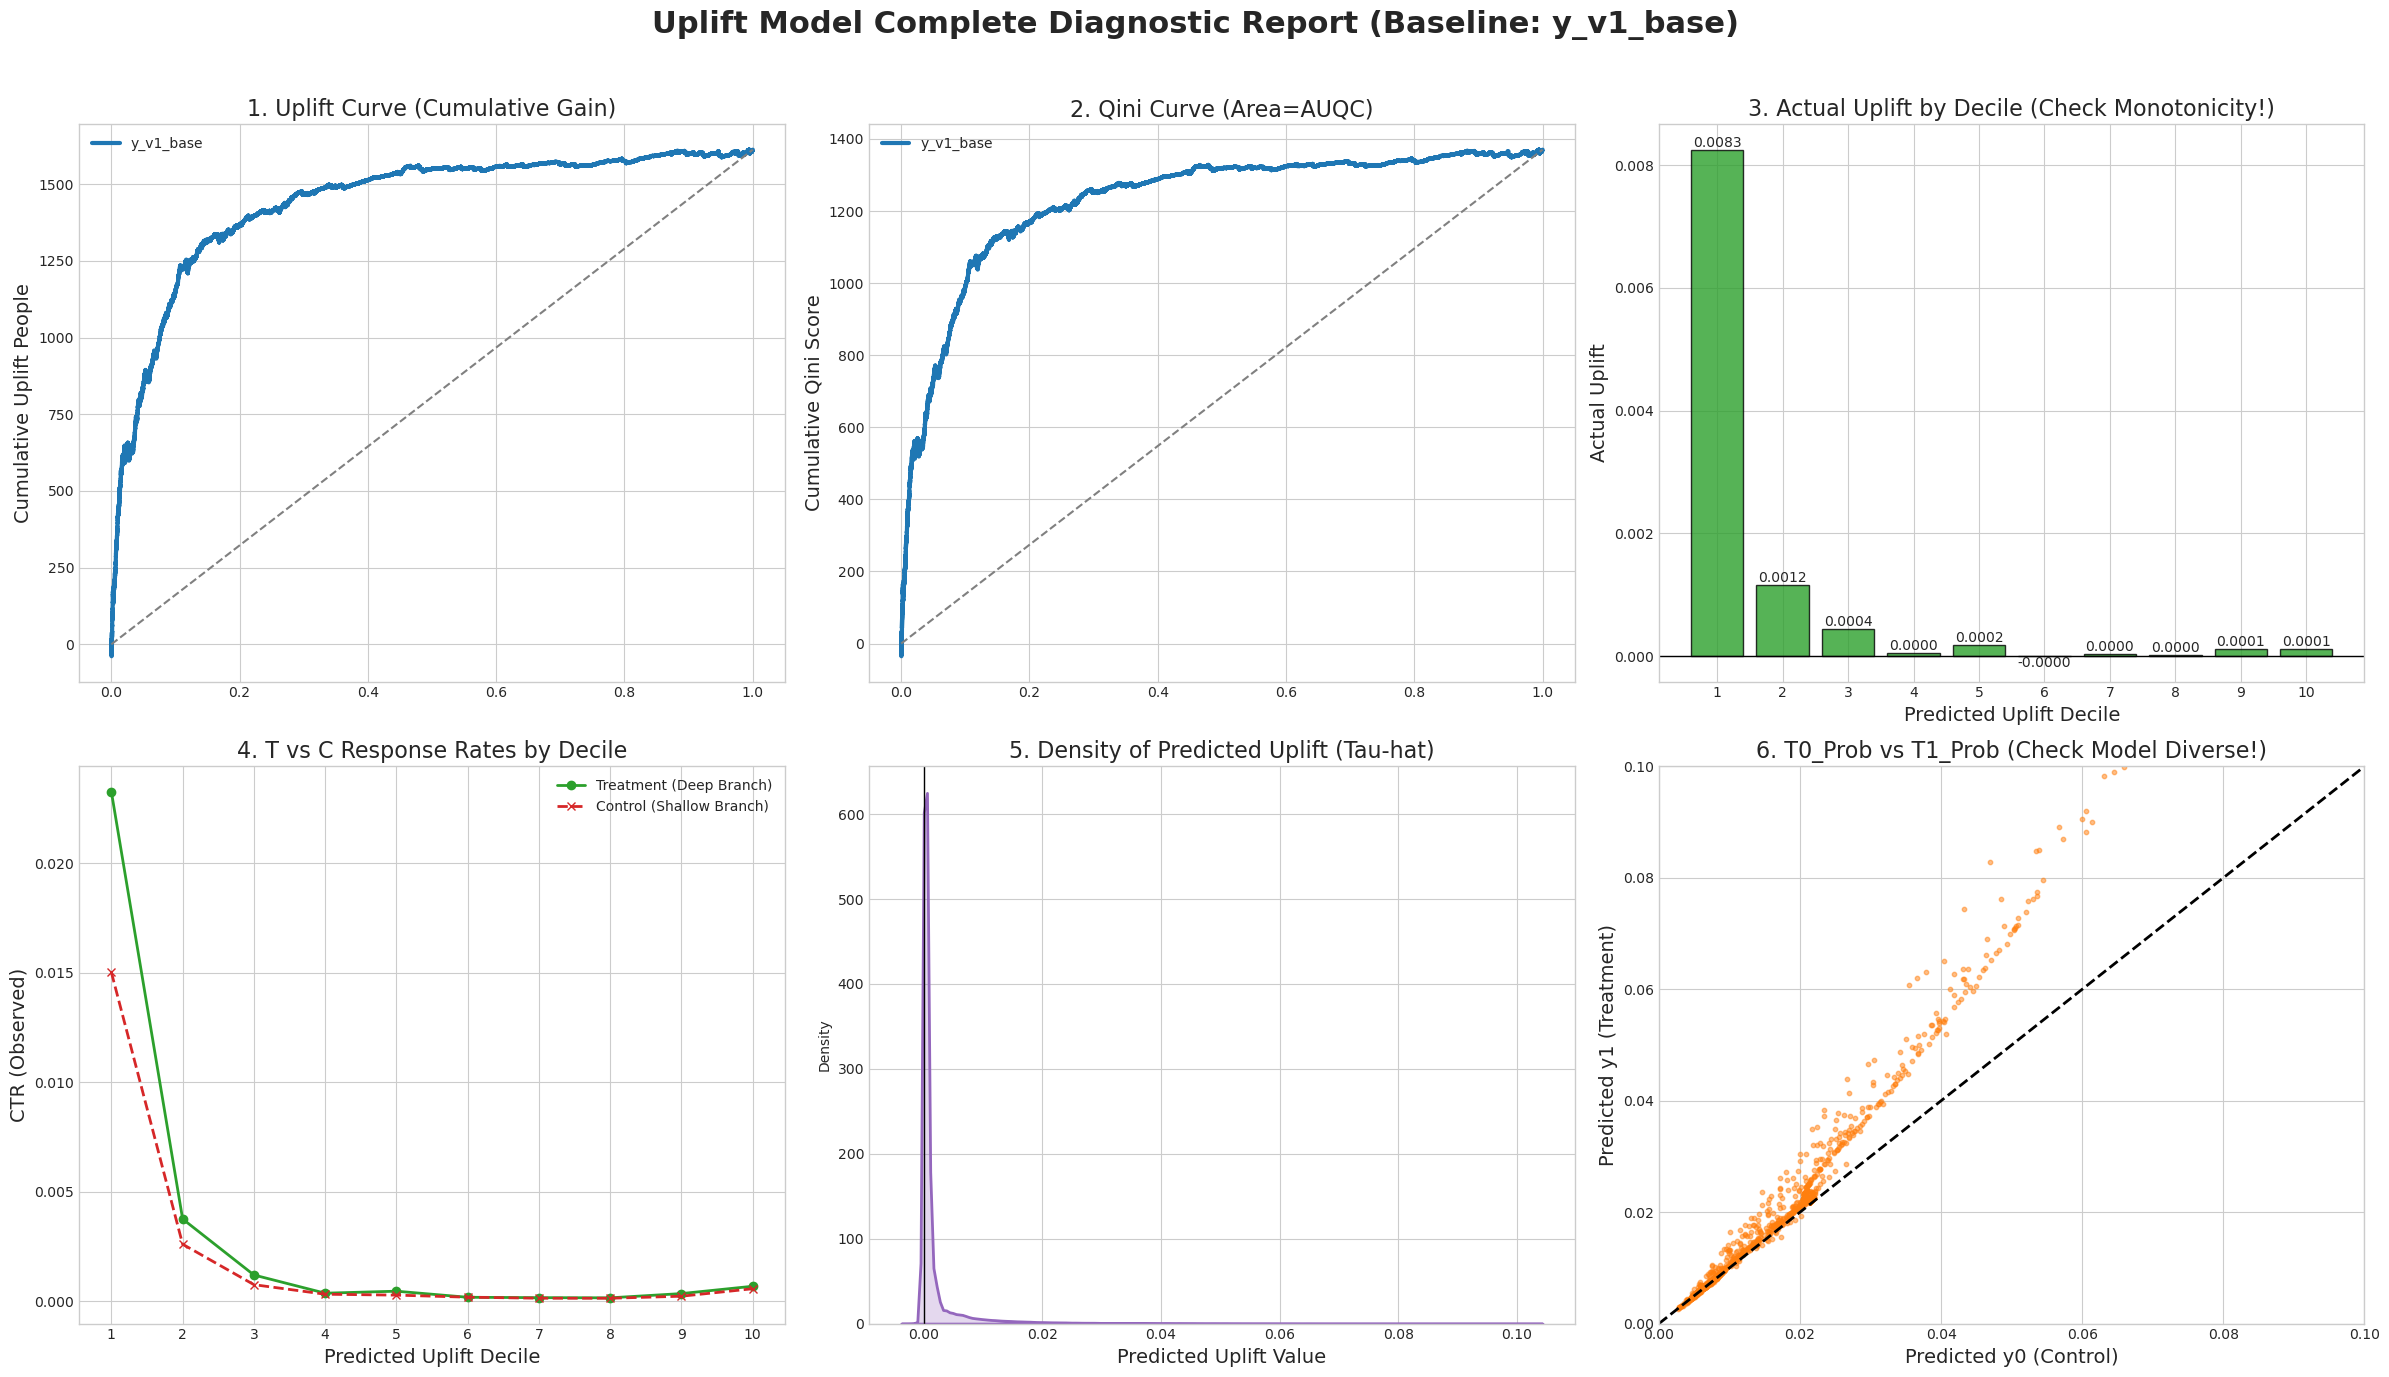

In [11]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v4_loss_strata"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v4_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v5_loss_var/run_v5_var/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v5_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


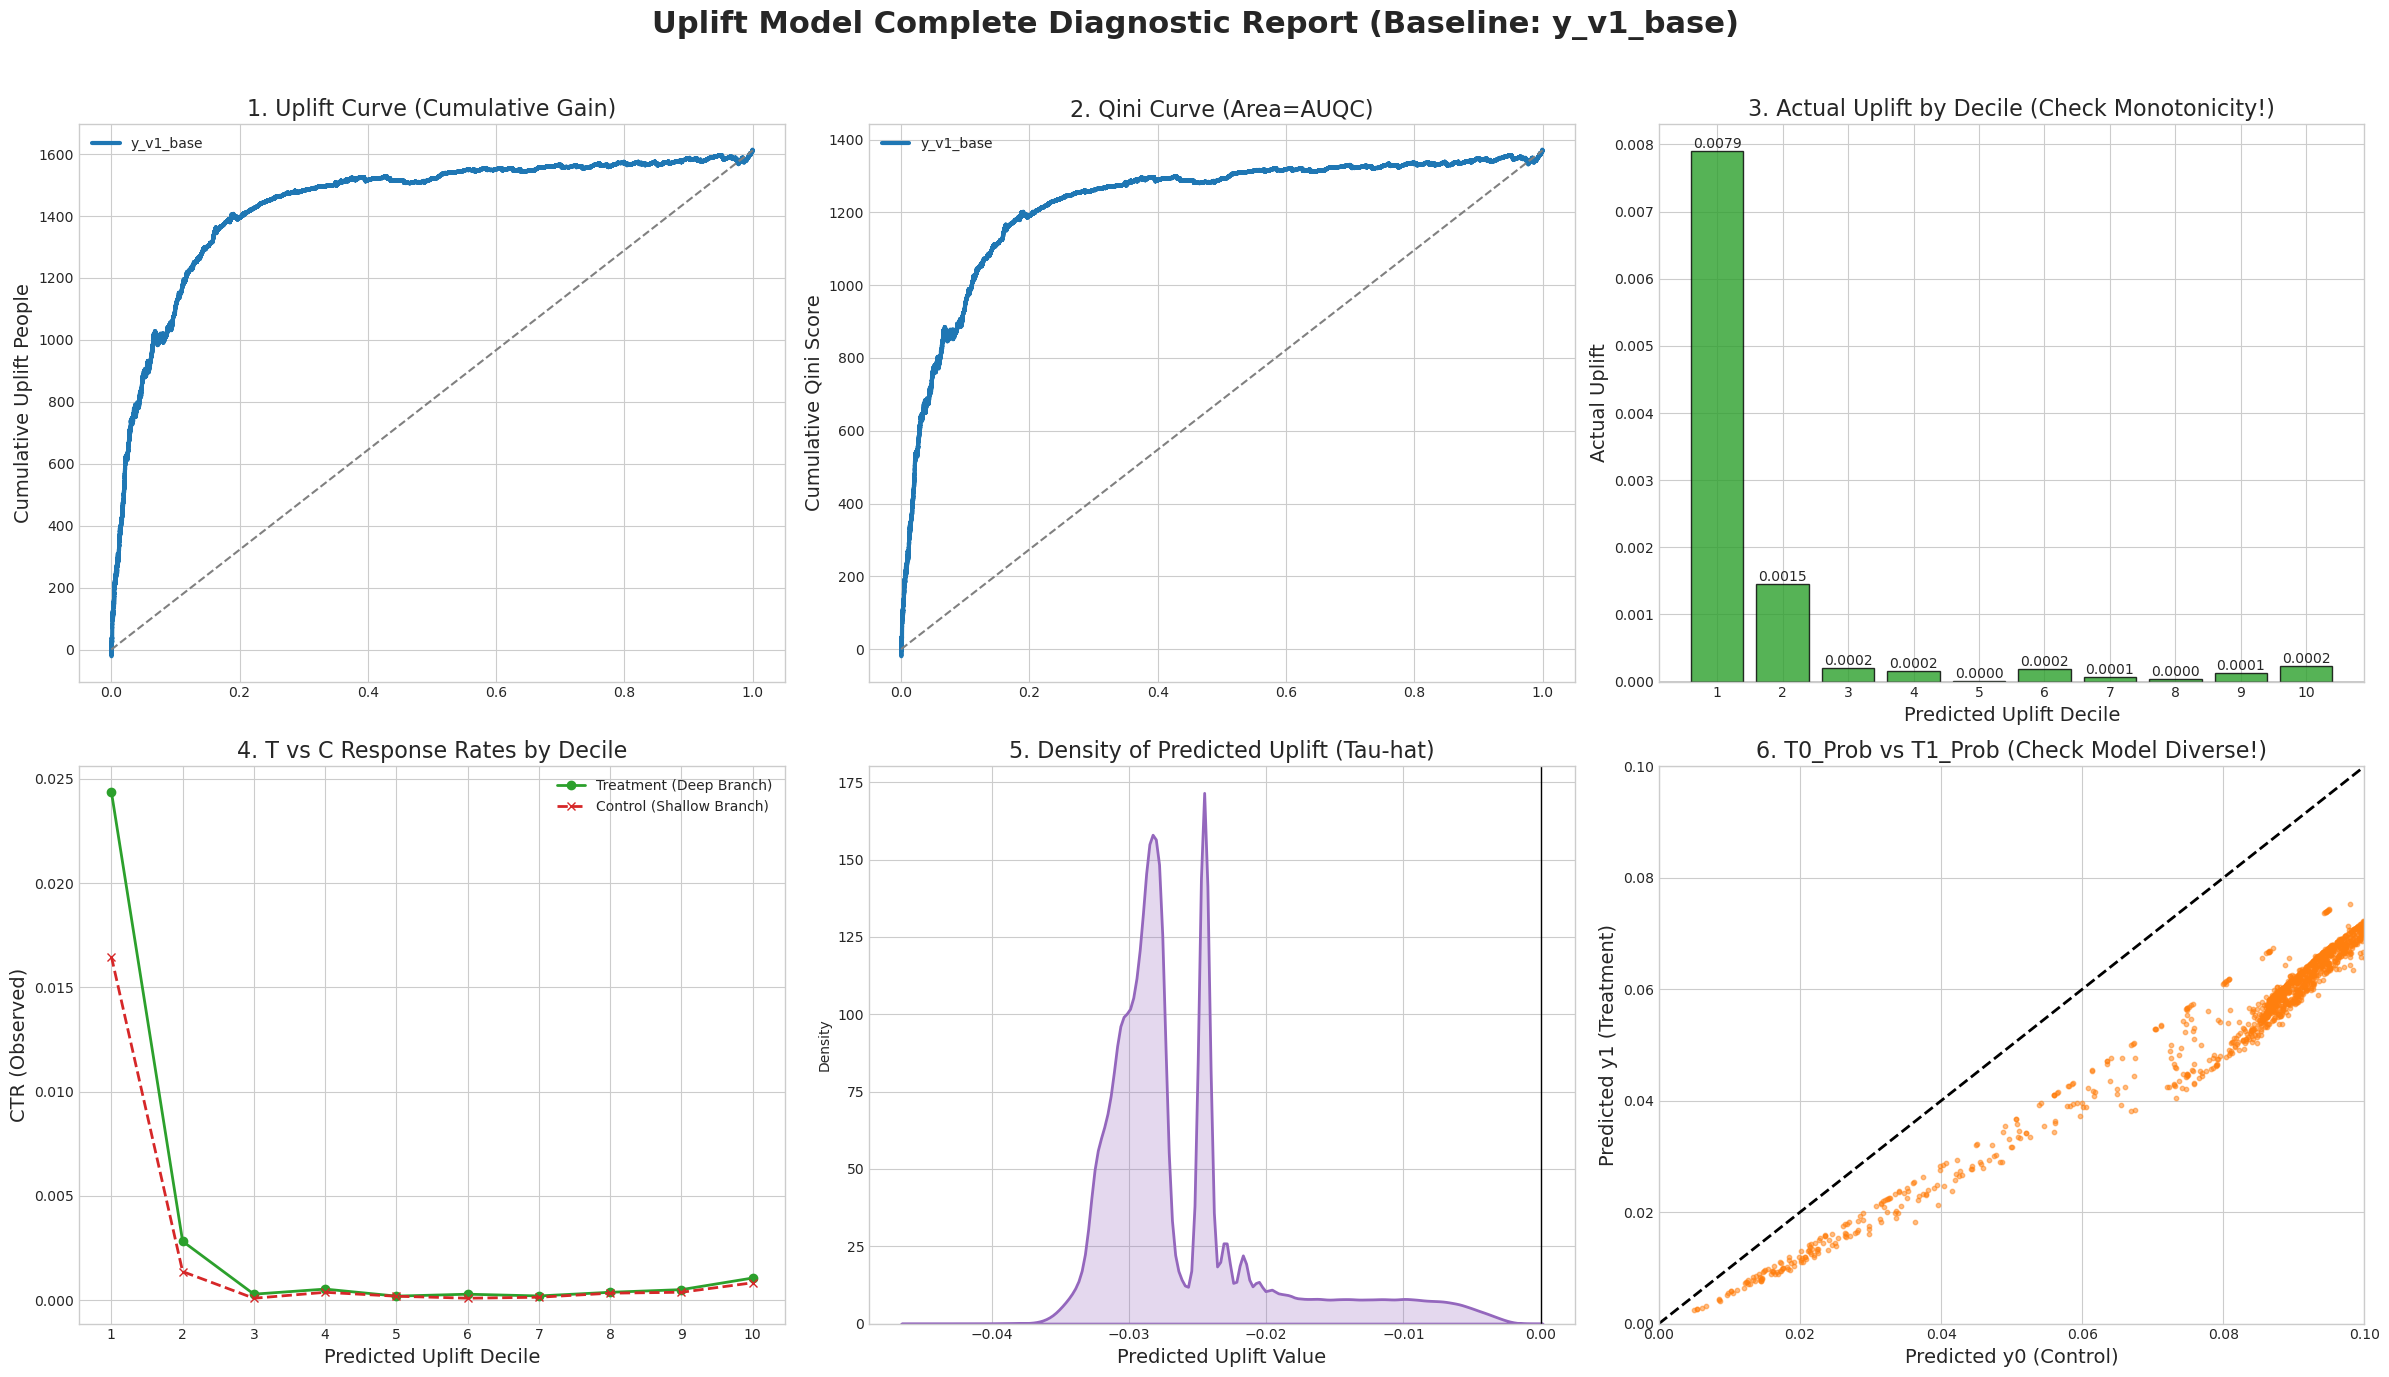

In [10]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v5_loss_var"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v5_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

In [22]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v3_path = find_csv("./results/criteo/train_y/TARNET/y_v3_moe")

if not all([c_path, v1_path, v3_path]):
    print("❌ 找不到文件，请检查路径！")
    exit()

print("🔍 正在加载数据并深度解析 Model C 的人群分层信号...")
df_c  = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v3 = pd.read_csv(v3_path)

# 核心数据对齐
df = pd.DataFrame({
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    't': df_c['t'],
    # C 模型的先验身份
    'p_always': df_c['y0_prob'],
    'p_complier': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'v1_uplift': df_v1['uplift_pred'],
    'v3_uplift': df_v3['uplift_pred']
})
# Never-taker 概率：1 - 总是转化 - 敏感转化
df['p_never'] = (1.0 - df['p_always'] - df['p_complier']).clip(lower=0)

# 使用 rank 打破平局进行 10 等分
df['complier_rank'] = df['p_complier'].rank(method='first')
df['complier_bin'] = pd.qcut(df['complier_rank'], q=10)

results = []
for bin_name, group in df.groupby('complier_bin', observed=True):
    t1_mask, t0_mask = (group['t'] == 1), (group['t'] == 0)
    
    # 计算真实增益 (Ground Truth)
    real_y1 = group.loc[t1_mask, 'y_true'].mean() if t1_mask.sum() > 0 else 0
    real_y0 = group.loc[t0_mask, 'y_true'].mean() if t0_mask.sum() > 0 else 0
    real_uplift = real_y1 - real_y0
    
    real_c1 = group.loc[t1_mask, 'c_true'].mean() if t1_mask.sum() > 0 else 0
    real_c0 = group.loc[t0_mask, 'c_true'].mean() if t0_mask.sum() > 0 else 0
    real_uplift_c = real_c1 - real_c0

    results.append({
        'Bin_Range': bin_name,
        'Real_Uplift_Y': real_uplift,
        'Real_Uplift_C': real_uplift_c,
        # 🌟 Model C 传递给 MoE 的先验信号均值
        'C_p_never': group['p_never'].mean(),
        'C_p_always': group['p_always'].mean(),
        'C_p_comp': group['p_complier'].mean(),
        # 模型输出
        # 'V1_Uplift': group['v1_uplift'].mean(),
        'V3_Uplift': group['v3_uplift'].mean(),
    })

res_df = pd.DataFrame(results).set_index('Bin_Range')

# 打印美化
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("\n" + "="*130)
print("🚀 [深度对质] 探究 Model C 先验分布如何影响 V1 vs V3 的预测决策")
print("="*130)
print(res_df)
print("="*130)

🔍 正在加载数据并深度解析 Model C 的人群分层信号...

🚀 [深度对质] 探究 Model C 先验分布如何影响 V1 vs V3 的预测决策
                        Real_Uplift_Y  Real_Uplift_C  C_p_never  C_p_always  C_p_comp  V3_Uplift
Bin_Range                                                                                       
(0.999, 139796.9]            0.000079      -0.000362   0.979029    0.020971  0.000000   0.000145
(139796.9, 279592.8]         0.000212      -0.001977   0.979004    0.020996  0.000000   0.000145
(279592.8, 419388.7]         0.000008       0.000588   0.978993    0.021007  0.000000   0.000145
(419388.7, 559184.6]         0.000149       0.002570   0.980762    0.019234  0.000004   0.000139
(559184.6, 698980.5]         0.000028       0.000912   0.992355    0.007358  0.000287   0.000136
(698980.5, 838776.4]         0.000114       0.000550   0.991333    0.008174  0.000492   0.000172
(838776.4, 978572.3]         0.000064       0.001257   0.986606    0.012456  0.000939   0.000168
(978572.3, 1118368.2]        0.000148       0.001

In [1]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v3_path = find_csv("./results/criteo/train_y/TARNET/y_v3_moe")

df_v1 = pd.read_csv(v1_path)
df_v3 = pd.read_csv(v3_path)

def get_cumulative_performance(df, score_col, cutoffs):
    """计算不同截止比例下的累计真实增益"""
    # 按预测分数降序排列
    df_sorted = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)
    n_total = len(df_sorted)
    
    cum_results = []
    for q in cutoffs:
        n_cutoff = int(n_total * q)
        top_k = df_sorted.iloc[:n_cutoff]
        
        t1 = top_k[top_k['t'] == 1]
        t0 = top_k[top_k['t'] == 0]
        
        # 计算该截止点下的累计 CTR
        ctr_t1 = t1['y_true'].mean() if len(t1) > 0 else 0
        ctr_t0 = t0['y_true'].mean() if len(t0) > 0 else 0
        
        # 累计增益率 (Incremental CTR)
        cum_uplift_rate = ctr_t1 - ctr_t0
        
        # 累计带来的额外转化人数 (Total Lift / Extra Conversions)
        # 公式: (CTR_t - CTR_c) * N_targeted
        extra_conversions = cum_uplift_rate * n_cutoff
        
        cum_results.append({
            'Cutoff (Top %)': f"{int(q*100)}%",
            'Target_Size': n_cutoff,
            'Cum_Uplift_Rate': cum_uplift_rate,
            'Extra_Conv': extra_conversions
        })
    return pd.DataFrame(cum_results).set_index('Cutoff (Top %)')

# 2. 定义你关心的截止点
my_cutoffs = [0.01, 0.05, 0.10, 0.15, 0.30]

print("🚀 正在计算 V1 和 V3 在不同预算截止点下的累计作战能力...")
v1_cum = get_cumulative_performance(df_v1, 'uplift_pred', my_cutoffs)
v3_cum = get_cumulative_performance(df_v3, 'uplift_pred', my_cutoffs)

# 3. 汇总对比
final_report = pd.DataFrame({
    'V1_Cum_Rate': v1_cum['Cum_Uplift_Rate'],
    'V3_Cum_Rate': v3_cum['Cum_Uplift_Rate'],
    'V1_Total_Gain': v1_cum['Extra_Conv'],
    'V3_Total_Gain': v3_cum['Extra_Conv'],
})

# 计算 V3 相对 V1 的绝对提升 (多赚了多少人) 和 相对提升 (%)
final_report['Gain_Diff (人数)'] = final_report['V3_Total_Gain'] - final_report['V1_Total_Gain']
final_report['Relative_Improve (%)'] = (final_report['V3_Cum_Rate'] / (final_report['V1_Cum_Rate'] + 1e-9) - 1) * 100

pd.set_option('display.float_format', '{:.6f}'.format)
print("\n" + "="*130)
print("🏆 [预算视角] V1 vs V3 累计增益对比战报 (如果我只投前 K% 的人，结果会怎样？)")
print("-" * 130)
print(final_report)
print("="*130)

print("\n💡 战报解读：")
for q in [1, 5, 10, 15, 30]:
    row = final_report.loc[f"{q}%"]
    better = "V3 胜出 ✅" if row['Gain_Diff (人数)'] > 0 else "V1 顽强守住 ❌"
    print(f" - 在 Top {q}% 截止处：{better} | 相对 V1 提升了 {row['Relative_Improve (%)']:.2f}%")

🚀 正在计算 V1 和 V3 在不同预算截止点下的累计作战能力...

🏆 [预算视角] V1 vs V3 累计增益对比战报 (如果我只投前 K% 的人，结果会怎样？)
----------------------------------------------------------------------------------------------------------------------------------
                V1_Cum_Rate  V3_Cum_Rate  V1_Total_Gain  V3_Total_Gain  \
Cutoff (Top %)                                                           
1%                 0.026038     0.033192     363.980504     463.989461   
5%                 0.010729     0.012780     749.912347     893.330812   
10%                0.008623     0.008200    1205.454895    1146.313562   
15%                0.006312     0.006159    1323.524756    1291.598931   
30%                0.003413     0.003459    1431.491960    1450.841630   

                Gain_Diff (人数)  Relative_Improve (%)  
Cutoff (Top %)                                        
1%                  100.008957             27.476455  
5%                  143.418465             19.124686  
10%                 -59.141333             -4

In [35]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 自动加载三个模型的数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v3_path = find_csv("./results/criteo/train_y/TARNET/y_v3_moe")

if not all([c_path, v1_path, v3_path]):
    print("❌ 找不到文件，请检查路径！")
    exit()

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v3 = pd.read_csv(v3_path)

# 2. 组装终极宽表
df = pd.DataFrame({
    't': df_c['t'],
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    # C 模型的先验预测
    'C_p_comp': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    # Y 模型的最终打分
    'v1_score': df_v1['uplift_pred'],
    'v3_score': df_v3['uplift_pred']
})

def analyze_top_k_composition(df, score_col, cutoffs):
    """按指定的分数降序排列，截取 Top K%，分析里面的成分浓度"""
    # 强行按模型自己的打分降序排！
    df_sorted = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)
    n_total = len(df_sorted)
    
    results = []
    for q in cutoffs:
        n_cutoff = int(n_total * q)
        top_k = df_sorted.iloc[:n_cutoff] # 圈出 Top K% 的人
        
        t1 = top_k[top_k['t'] == 1]
        t0 = top_k[top_k['t'] == 0]
        
        # 1. 真实 Y 增益 (真金白银的购买 Complier 浓度)
        real_y1 = t1['y_true'].mean() if len(t1) > 0 else 0
        real_y0 = t0['y_true'].mean() if len(t0) > 0 else 0
        real_uplift_y = real_y1 - real_y0
        
        # 2. 真实 C 增益 (真实的点击 Complier 浓度)
        real_c1 = t1['c_true'].mean() if len(t1) > 0 else 0
        real_c0 = t0['c_true'].mean() if len(t0) > 0 else 0
        real_uplift_c = real_c1 - real_c0
        
        # 3. Model C 对这群人的预期 (C模型当时是怎么看这群人的？)
        c_pred_comp = top_k['C_p_comp'].mean()
        
        results.append({
            'Top_%': f"{int(q*100)}%",
            f'{score_col}_Real_Y': real_uplift_y,
            f'{score_col}_Real_C': real_uplift_c,
            f'{score_col}_C_Pred': c_pred_comp
        })
    return pd.DataFrame(results).set_index('Top_%')

# 3. 定义截断点 (我们要看最头部的极高纯度，以及往后延伸的稀释过程)
cutoffs = [0.01,0.05,0.075, 0.10, 0.15, 0.30]

print("🔬 正在进行 Top K% 人群成分的深度核磁共振...")
v1_comp = analyze_top_k_composition(df, 'v1_score', cutoffs)
v3_comp = analyze_top_k_composition(df, 'v3_score', cutoffs)

# 4. 拼装成无敌对比表
report = pd.DataFrame({
    # --- Y 任务真实增益 (我们在帮公司赚多少钱？) ---
    'V1_Real_Y': v1_comp['v1_score_Real_Y'],
    'V3_Real_Y': v3_comp['v3_score_Real_Y'],
    # --- C 任务真实增益 (这群人真的爱点广告吗？) ---
    'V1_Real_C': v1_comp['v1_score_Real_C'],
    'V3_Real_C': v3_comp['v3_score_Real_C'],
    # --- C 模型的先验心智 (C 当时看好他们吗？) ---
    'V1_pred_C': v1_comp['v1_score_C_Pred'],
    'V3_pred_C': v3_comp['v3_score_C_Pred'],
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.6f}'.format)

print("\n" + "="*140)
print("🔥 [灵魂铁证] Top K% 截断人群的真实成分剖析 (V1自选 vs V3自选)")
print("="*140)
print(report)
print("="*140)

🔬 正在进行 Top K% 人群成分的深度核磁共振...

🔥 [灵魂铁证] Top K% 截断人群的真实成分剖析 (V1自选 vs V3自选)
       V1_Real_Y  V3_Real_Y  V1_Real_C  V3_Real_C  V1_pred_C  V3_pred_C
Top_%                                                                  
1%      0.026038   0.033192   0.101399   0.098901   0.097203   0.133423
5%      0.010729   0.012780   0.061683   0.074574   0.063544   0.087410
7%      0.009784   0.009969   0.053513   0.061037   0.052138   0.069844
10%     0.008623   0.008200   0.050094   0.052041   0.044348   0.056850
15%     0.006312   0.006159   0.041489   0.043599   0.034811   0.042203
30%     0.003413   0.003459   0.026981   0.028882   0.020736   0.024483


In [32]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 我们这次只请主角 Model C 出场
c_path = find_csv("./results/criteo/train_c/TARNET/c_v1_base")

if not c_path:
    print("❌ 找不到 Model C 的 test_dist.csv，请检查路径！")
    exit()

print("🔍 正在加载 Model C 的数据，准备进行深度校准测谎...")
df_c = pd.read_csv(c_path)

# 计算 C 模型预测的点击增益
df_c['C_p_comp'] = (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0)

# 强行按 C 模型的预测分降序排列，切成 20 个细粒度的桶 (每桶 5%)
df_c['rank'] = df_c['C_p_comp'].rank(method='first', ascending=False)
df_c['bin_20'] = pd.qcut(df_c['rank'], q=20, labels=range(1, 21))

results = []
for bin_id, group in df_c.groupby('bin_20', observed=True):
    t1 = group[group['t'] == 1]
    t0 = group[group['t'] == 0]
    
    # 计算现实中发生的真实 点击增益
    real_c1 = t1['c_true'].mean() if len(t1) > 0 else 0
    real_c0 = t0['c_true'].mean() if len(t0) > 0 else 0
    real_uplift_c = real_c1 - real_c0
    
    # C 模型在这个桶里的平均预测增益
    pred_uplift_c = group['C_p_comp'].mean()
    
    # 绝对误差：预期 - 现实
    error = pred_uplift_c - real_uplift_c
    
    results.append({
        'Top_%_Range': f"{(bin_id-1)*5:>2}% - {bin_id*5:>2}%",
        'C_Pred_Uplift (预期)': pred_uplift_c,
        'Real_C_Uplift (现实)': real_uplift_c,
        'Abs_Error (绝对误差)': error
    })

res_df = pd.DataFrame(results).set_index('Top_%_Range')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.6f}'.format)

print("\n" + "="*100)
print("⚖️ [Model C 测谎仪] 预期 vs 现实：20 档人群的精细化校准检验")
print("="*100)
print(res_df)
print("="*100)

# 特别提取头部和尾部的对比
top_5_pred = res_df.iloc[0]['C_Pred_Uplift (预期)']
top_5_real = res_df.iloc[0]['Real_C_Uplift (现实)']

bottom_5_pred = res_df.iloc[-1]['C_Pred_Uplift (预期)']
bottom_5_real = res_df.iloc[-1]['Real_C_Uplift (现实)']

print("\n💡 核心论点验证 (用于论文)：")
print(f"👉 【头部精准度 (Top 0-5%)】: C 预测 {top_5_pred:.6f}，现实 {top_5_real:.6f}。")
print(f"👉 【尾部失效区 (Bottom 95-100%)】: C 预测 {bottom_5_pred:.6f}，现实 {bottom_5_real:.6f}。")

🔍 正在加载 Model C 的数据，准备进行深度校准测谎...

⚖️ [Model C 测谎仪] 预期 vs 现实：20 档人群的精细化校准检验
             C_Pred_Uplift (预期)  Real_C_Uplift (现实)  Abs_Error (绝对误差)
Top_%_Range                                                          
 0% -  5%              0.093033            0.086005          0.007028
 5% - 10%              0.033509            0.030495          0.003013
10% - 15%              0.012877            0.009795          0.003082
15% - 20%              0.005124            0.006052         -0.000928
20% - 25%              0.003476            0.000764          0.002712
25% - 30%              0.002174            0.001368          0.000806
30% - 35%              0.001209            0.001899         -0.000690
35% - 40%              0.000669            0.000628          0.000041
40% - 45%              0.000533            0.000401          0.000132
45% - 50%              0.000452            0.000735         -0.000283
50% - 55%              0.000380            0.000691         -0.000311
55% - 60%      

In [1]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v3_path = find_csv("./results/criteo/train_y/TARNET/y_v3_moe")

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v3 = pd.read_csv(v3_path)

# 2. 预处理
df = pd.DataFrame({
    't': df_c['t'],
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    'C_p_comp': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'C_p_never': (1.0 - df_c['y1_prob']).clip(lower=0), # 简化：1 - p(y1) 认为是绝不转化
    'v1_score': df_v1['uplift_pred'],
    'v3_score': df_v3['uplift_pred']
})

# 计算分位数标签，方便筛选“极其看好”和“极其不看好”
df['v1_rank_pct'] = df['v1_score'].rank(pct=True, ascending=False) # 0是最高，1是最低
df['c_rank_pct']  = df['C_p_comp'].rank(pct=True, ascending=False)

def get_real_uplift(group):
    t1 = group[group['t'] == 1]
    t0 = group[group['t'] == 0]
    real_y = t1['y_true'].mean() - t0['y_true'].mean() if (len(t1)>0 and len(t0)>0) else 0
    real_c = t1['c_true'].mean() - t0['c_true'].mean() if (len(t1)>0 and len(t0)>0) else 0
    return real_y, real_c

# =================================================================
# 3. 定义四个分歧象限
# =================================================================

# 象限 A: V1 的假阳性陷阱 (V1看好 Top 10%，但 C 判死刑 p_never > 0.9)
mask_a = (df['v1_rank_pct'] <= 0.10) & (df['c_rank_pct'] > 0.50)

# 象限 B: C 的慧眼识珠 (C看好 Top 10%，但 V1 没瞧上 后 50%)
mask_b = (df['c_rank_pct'] <= 0.10) & (df['v1_rank_pct'] > 0.50)

# 象限 C: 双强共识 (V1 和 C 都看好 Top 10%)
mask_c = (df['v1_rank_pct'] <= 0.10) & (df['c_rank_pct'] <= 0.10)

quadrants = [
    ("C top 10%, V1 bottom 50%", mask_b),
    ("V1 top 10%, C bottom 50%", mask_a),
    ("双强共识区 (Both High)", mask_c)
]

print("\n" + "="*120)
print(f"{'冲突象限分析':^120}")
print("="*120)
print(f"{'象限名称':<30} | {'样本量':<8} | {'真实Y增益':<8} | {'真实C增益':<8} | {'V1预估':<8} | {'V3预估':<12} | {'C预估':<12}")
print("-" * 120)

for name, mask in quadrants:
    group = df[mask]
    if len(group) == 0: continue
    
    ry, rc = get_real_uplift(group)
    v1_avg = group['v1_score'].mean()
    v3_avg = group['v3_score'].mean()
    c_avg = group['C_p_comp'].mean()
    
    print(f"{name:<30} | {len(group):<8} | {ry:^12.6f} | {rc:^12.6f} | {v1_avg:^12.6f} | {v3_avg:^12.6f} | {c_avg:^12.6f}")

print("="*120)


                                                         冲突象限分析                                                         
象限名称                           | 样本量      | 真实Y增益    | 真实C增益    | V1预估     | V3预估         | C预估         
------------------------------------------------------------------------------------------------------------------------
C top 10%, V1 bottom 50%       | 17384    |   0.000110   |   0.045071   |  -0.000227   |   0.002116   |   0.050770  
V1 top 10%, C bottom 50%       | 42845    |   0.001045   |   0.003667   |   0.003040   |   0.000955   |   0.000003  
双强共识区 (Both High)              | 77842    |   0.012483   |   0.071143   |   0.009733   |   0.010486   |   0.077122  


In [2]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v3_path = find_csv("./results/criteo/train_y/TARNET/y_v3_moe")

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v3 = pd.read_csv(v3_path)

# 2. 组装数据并计算核心排名 (0.0=第一名, 1.0=最后一名)
df = pd.DataFrame({
    't': df_c['t'],
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    'C_p_comp': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'v1_score': df_v1['uplift_pred'],
    'v3_score': df_v3['uplift_pred']
})

# 🌟 关键：计算所有模型在大盘中的“排名位置”
df['v1_pos'] = df['v1_score'].rank(pct=True, ascending=False)
df['v3_pos'] = df['v3_score'].rank(pct=True, ascending=False)
df['c_pos']  = df['C_p_comp'].rank(pct=True, ascending=False)

def get_real_uplift(group):
    t1 = group[group['t'] == 1]
    t0 = group[group['t'] == 0]
    real_y = t1['y_true'].mean() - t0['y_true'].mean() if (len(t1)>0 and len(t0)>0) else 0
    return real_y

# 3. 定义四个分歧战场
# 战场 A: C 强推, V1 抛弃 (测 C 的含金量)
mask_a = (df['c_pos'] <= 0.10) & (df['v1_pos'] > 0.50)
# 战场 B: V1 强推, C 判死刑 (测 V1 的清醒度)
mask_b = (df['v1_pos'] <= 0.10) & (df['c_pos'] > 0.50)
# 对照区: 双强共识
mask_c = (df['v1_pos'] <= 0.10) & (df['c_pos'] <= 0.10)

quadrants = [
    ("【战场 A】C High, V1 Low", mask_a),
    ("【战场 B】V1 High, C Low", mask_b),
    ("【对照区】Both High", mask_c)
]

print("\n" + "="*140)
print(f"{'⚖️ 冲突象限位置与成分透视 (位置越接近 0.0 越靠前)':^140}")
print("="*140)
print(f"{'象限名称':<25} | {'样本量':<8} | {'Real_Y':<10} | {'V1位置':<10} | {'V3位置':<10} | {'C位置':<10} | {'位置位移(V3-V1)':<12}")
print("-" * 140)

for name, mask in quadrants:
    group = df[mask]
    if len(group) == 0: continue
    
    ry = get_real_uplift(group)
    v1_p = group['v1_pos'].mean()
    v3_p = group['v3_pos'].mean()
    cp   = group['c_pos'].mean()
    shift = v3_p - v1_p # 负数代表 V3 把这群人提拔了，正数代表打压了
    
    print(f"{name:<25} | {len(group):<8} | {ry:^10.6f} | {v1_p:^10.4f} | {v3_p:^10.4f} | {cp:^10.4f} | {shift:^14.4f}")

print("="*140)


                                                       ⚖️ 冲突象限位置与成分透视 (位置越接近 0.0 越靠前)                                                       
象限名称                      | 样本量      | Real_Y     | V1位置       | V3位置       | C位置        | 位置位移(V3-V1) 
--------------------------------------------------------------------------------------------------------------------------------------------
【战场 A】C High, V1 Low      | 17384    |  0.000110  |   0.8716   |   0.1289   |   0.0595   |    -0.7427    
【战场 B】V1 High, C Low      | 42845    |  0.001045  |   0.0660   |   0.1074   |   0.8034   |     0.0415    
【对照区】Both High            | 77842    |  0.012483  |   0.0405   |   0.0330   |   0.0399   |    -0.0075    


In [3]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据并对齐
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v3_path = find_csv("./results/criteo/train_y/TARNET/y_v3_moe")

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v3 = pd.read_csv(v3_path)

df = pd.DataFrame({
    't': df_c['t'],
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    'C_p_comp': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'v1_score': df_v1['uplift_pred'],
    'v3_score': df_v3['uplift_pred']
})

# 计算全盘排名位置
df['v1_pos'] = df['v1_score'].rank(pct=True, ascending=False)
df['v3_pos'] = df['v3_score'].rank(pct=True, ascending=False)

# =================================================================
# 🔍 核心透视点：在 5%-30% 区间，V3 到底用谁换掉了谁？
# =================================================================
cutoff = 0.05 # 我们观察前 15% 的换血情况
n_cutoff = int(len(df) * cutoff)

v1_top_set = set(df[df['v1_pos'] <= cutoff].index)
v3_top_set = set(df[df['v3_pos'] <= cutoff].index)

# 群组 1: V3 提拔的新贵 (V3 Top 15% 但 V1 不看好)
v3_exclusive = list(v3_top_set - v1_top_set)
# 群组 2: V1 坚守的老臣 (V1 Top 15% 但 V3 抛弃)
v1_exclusive = list(v1_top_set - v3_top_set)
# 群组 3: 绝对头部 (两者共识的 Top 15%)
both_common = list(v1_top_set.intersection(v3_top_set))

def get_stats(indices, name):
    group = df.loc[indices]
    t1 = group[group['t'] == 1]
    t0 = group[group['t'] == 0]
    
    # 真实增益计算
    y_lift = t1['y_true'].mean() - t0['y_true'].mean()
    c_lift = t1['c_true'].mean() - t0['c_true'].mean()
    
    # 🌟 关键指标：因果转换效率 (Causal Efficiency)
    # 物理意义：每增加一个点击，能带来多少额外的转化？
    efficiency = y_lift / (c_lift + 1e-6)
    
    return {
        '人群分类': name,
        '样本量': len(indices),
        'Y_Uplift (转化增益)': y_lift,
        'C_Uplift (点击增益)': c_lift,
        'C2Y_Efficiency (转化效率)': efficiency,
        'ModelC_Prior (导师打分)': group['C_p_comp'].mean()
    }

analysis = pd.DataFrame([
    get_stats(both_common, "【共识区】两者都看好"),
    get_stats(v3_exclusive, "【V3提拔】"),
    get_stats(v1_exclusive, "【V1坚守】")
])

print("\n" + "="*120)
print(f"📊 前5%")
print("-" * 120)
print(analysis.to_string(index=False))
print("="*120)


📊 前5%
------------------------------------------------------------------------------------------------------------------------
      人群分类   样本量  Y_Uplift (转化增益)  C_Uplift (点击增益)  C2Y_Efficiency (转化效率)  ModelC_Prior (导师打分)
【共识区】两者都看好 46783         0.012856         0.079330               0.162059             0.089784
    【V3提拔】 23115         0.011238         0.056746               0.198044             0.082605
    【V1坚守】 23115         0.000819         0.006846               0.119639             0.010435


In [4]:
# =================================================================
# 🔍 核心透视点：分段进行“人员换血”体检
# =================================================================

def analyze_bin(df, start_pct, end_pct):
    print(f"\n" + "="*120)
    print(f"📊 正在透视区间: [{start_pct*100:.0f}% - {end_pct*100:.0f}%]")
    print("-" * 120)
    
    # 获取在该区间内的人群索引 (注意这里是区间，不是累计)
    v1_bin_set = set(df[(df['v1_pos'] > start_pct) & (df['v1_pos'] <= end_pct)].index)
    v3_bin_set = set(df[(df['v3_pos'] > start_pct) & (df['v3_pos'] <= end_pct)].index)
    
    # 找分歧
    v3_exclusive = list(v3_bin_set - v1_bin_set)
    v1_exclusive = list(v1_bin_set - v3_bin_set)
    both_common = list(v1_bin_set.intersection(v3_bin_set))
    
    analysis = pd.DataFrame([
        get_stats(both_common, "【共识区】两者都看好"),
        get_stats(v3_exclusive, "【V3提拔】(C强Y弱?)"),
        get_stats(v1_exclusive, "【V1坚守】(C弱Y强?)")
    ])
    
    # 打印排版好的表格
    pd.set_option('display.float_format', '{:.6f}'.format)
    print(analysis.to_string(index=False))

# 定义你想透视的独立区间
bins = [
    (0.0, 0.05),   # 0-5%: V3 为什么能赢？
    (0.05, 0.10),  # 5-10%: V3 为什么开始掉点？
    (0.10, 0.20),
    (0.20, 0.30),   # 10-30%: V3 彻底陷入泥潭的原因？
    (0.30, 0.50),
    (0.5, 0.9)
]

for start, end in bins:
    analyze_bin(df, start, end)


📊 正在透视区间: [0% - 5%]
------------------------------------------------------------------------------------------------------------------------
         人群分类   样本量  Y_Uplift (转化增益)  C_Uplift (点击增益)  C2Y_Efficiency (转化效率)  ModelC_Prior (导师打分)
   【共识区】两者都看好 46783         0.012856         0.079330               0.162059             0.089784
【V3提拔】(C强Y弱?) 23115         0.011238         0.056746               0.198044             0.082605
【V1坚守】(C弱Y强?) 23115         0.000819         0.006846               0.119639             0.010435

📊 正在透视区间: [5% - 10%]
------------------------------------------------------------------------------------------------------------------------
         人群分类   样本量  Y_Uplift (转化增益)  C_Uplift (点击增益)  C2Y_Efficiency (转化效率)  ModelC_Prior (导师打分)
   【共识区】两者都看好 23200         0.003549         0.030118               0.117843             0.020022
【V3提拔】(C强Y弱?) 46698         0.000505         0.012135               0.041622             0.029403
【V1坚守】(C弱Y强?) 46698         0

In [5]:
import pandas as pd

# =================================================================
# 🔍 核心透视点：全局“换血对账单”提取
# =================================================================

def analyze_bin_summary(df, start_pct, end_pct):
    # 获取在该区间内的人群索引
    v1_bin_set = set(df[(df['v1_pos'] > start_pct) & (df['v1_pos'] <= end_pct)].index)
    v3_bin_set = set(df[(df['v3_pos'] > start_pct) & (df['v3_pos'] <= end_pct)].index)
    
    # 找分歧
    v3_exclusive = list(v3_bin_set - v1_bin_set)
    v1_exclusive = list(v1_bin_set - v3_bin_set)
    
    # 提取统计特征
    v3_stats = get_stats(v3_exclusive, "V3提拔")
    v1_stats = get_stats(v1_exclusive, "V1坚守")
    
    # 计算 V3 换血带来的“净利润” (V3提拔 - V1坚守)
    y_net_profit = v3_stats['Y_Uplift (转化增益)'] - v1_stats['Y_Uplift (转化增益)']
    c_net_profit = v3_stats['C_Uplift (点击增益)'] - v1_stats['C_Uplift (点击增益)']
    
    return {
        '区间 (Top %)': f"{start_pct*100:.0f}% - {end_pct*100:.0f}%",
        '换血规模': len(v3_exclusive),
        
        # --- Y 转化维度的对账 ---
        'V3提拔_Y增益': v3_stats['Y_Uplift (转化增益)'],
        'V1坚守_Y增益': v1_stats['Y_Uplift (转化增益)'],
        '🚨 Y增益_净亏损/盈利': y_net_profit,
        
        # --- C 点击维度的对账 ---
        'V3提拔_C增益': v3_stats['C_Uplift (点击增益)'],
        'V1坚守_C增益': v1_stats['C_Uplift (点击增益)'],
        
        # --- C导师打分对比 ---
        'V3提拔_C先验': v3_stats['ModelC_Prior (导师打分)'],
        'V1坚守_C先验': v1_stats['ModelC_Prior (导师打分)']
    }

# 定义你想透视的独立区间
bins = [
    (0.0, 0.05),
    (0.05, 0.10),
    (0.10, 0.20),
    (0.20, 0.30),
    (0.30, 0.50),
    (0.5, 0.9)
]

print("\n" + "="*140)
print(f"⚖️ 【全局换血对账单】 V3 强行干预到底赚了还是亏了？")
print("="*140)

summary_results = []
for start, end in bins:
    summary_results.append(analyze_bin_summary(df, start, end))

summary_df = pd.DataFrame(summary_results)
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(summary_df.to_string(index=False))
print("="*140)


⚖️ 【全局换血对账单】 V3 强行干预到底赚了还是亏了？
区间 (Top %)   换血规模  V3提拔_Y增益  V1坚守_Y增益  🚨 Y增益_净亏损/盈利  V3提拔_C增益  V1坚守_C增益  V3提拔_C先验  V1坚守_C先验
   0% - 5%  23115  0.011238  0.000819      0.010419  0.056746  0.006846  0.082605  0.010435
  5% - 10%  46698  0.000505  0.006187     -0.005682  0.012135  0.027986  0.029403  0.027700
 10% - 20%  69780  0.001206  0.000983      0.000223  0.015437  0.015240  0.013440  0.017457
 20% - 30% 129194  0.000156  0.000095      0.000061  0.003907  0.004325  0.005205  0.004400
 30% - 50% 278939  0.000066  0.000140     -0.000074  0.001145  0.000351  0.000968  0.001106
 50% - 90% 291416  0.000046  0.000191     -0.000145 -0.000321  0.002833  0.000303  0.002428


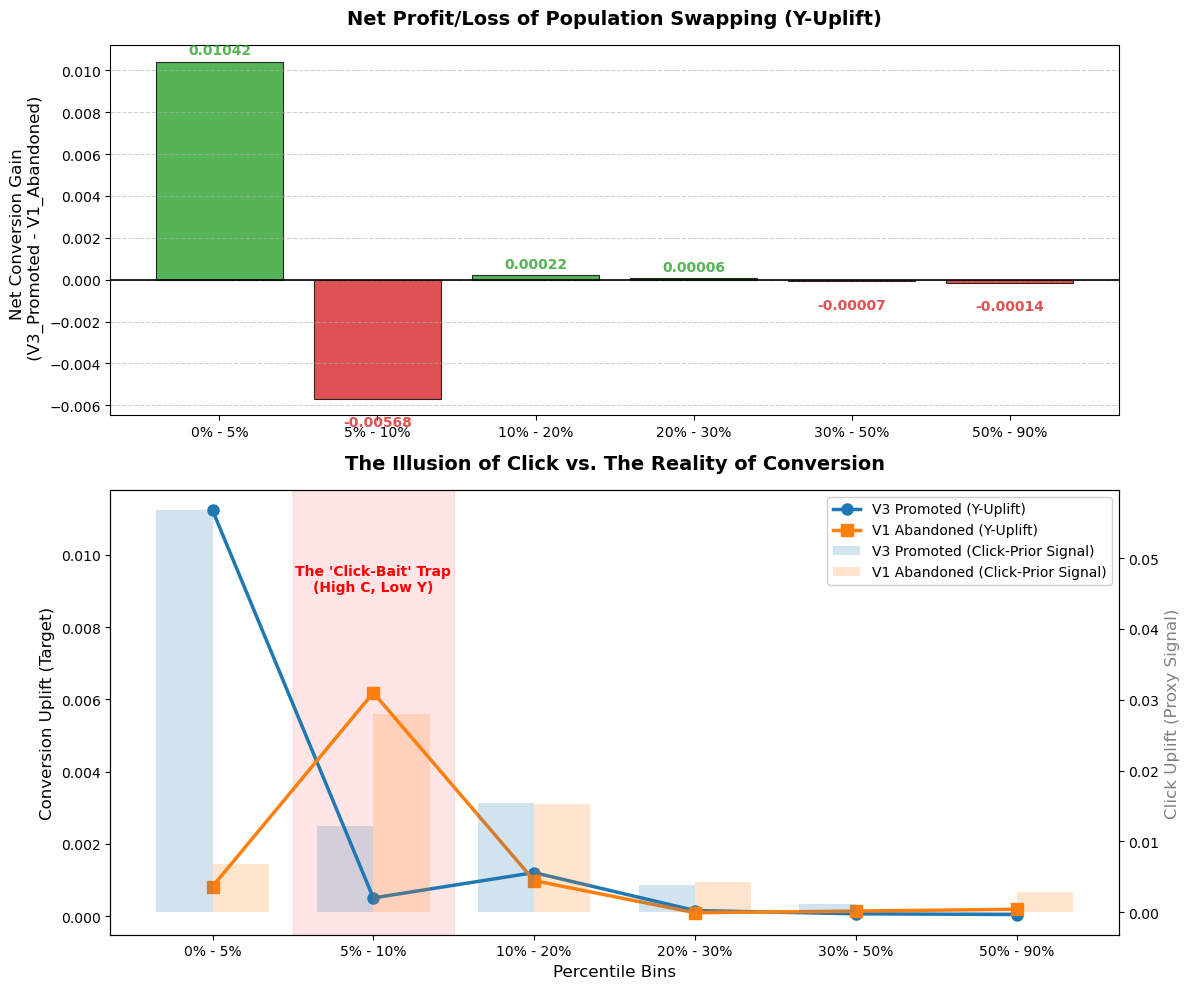

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_swapping_analysis(summary_df):
    # 1. 数据准备
    # 将中文标签映射为英文标签以适配论文
    bins = summary_df['区间 (Top %)'].tolist()
    net_y = summary_df['🚨 Y增益_净亏损/盈利'].tolist()
    
    v3_y = summary_df['V3提拔_Y增益'].tolist()
    v1_y = summary_df['V1坚守_Y增益'].tolist()
    
    v3_c = summary_df['V3提拔_C增益'].tolist()
    v1_c = summary_df['V1坚守_C增益'].tolist()

    # 2. 创建画布
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1, 1.2]})
    plt.subplots_adjust(hspace=0.35)

    # --- TOP CHART: Net Conversion Profit/Loss ---
    # 颜色逻辑：盈利为绿，亏损为红
    colors = ['#2ca02c' if x > 0 else '#d62728' for x in net_y]
    bars = ax1.bar(bins, net_y, color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)
    
    ax1.axhline(0, color='black', linewidth=1.2)
    ax1.set_title("Net Profit/Loss of Population Swapping (Y-Uplift)", fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel("Net Conversion Gain \n (V3_Promoted - V1_Abandoned)", fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.6)

    # 在柱状图上标注具体数值
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + (0.0002 if yval > 0 else -0.0008), 
                 f'{yval:.5f}', ha='center', va='bottom' if yval > 0 else 'top', 
                 fontsize=10, fontweight='bold', color=bar.get_facecolor())

    # --- BOTTOM CHART: Click vs. Conversion (The Root Cause) ---
    # 我们对比 V3 提拔的人和 V1 坚守的人
    x = np.arange(len(bins))
    width = 0.35

    # 绘制 Y-Uplift (实线 + 标记) -> 代表真实价值
    ax2.plot(x, v3_y, marker='o', label='V3 Promoted (Y-Uplift)', color='#1f77b4', linewidth=2.5, markersize=8)
    ax2.plot(x, v1_y, marker='s', label='V1 Abandoned (Y-Uplift)', color='#ff7f0e', linewidth=2.5, markersize=8)

    # 绘制 C-Uplift (阴影柱状图) -> 代表诱导信号
    ax2_c = ax2.twinx() # 双坐标轴
    ax2_c.bar(x - width/2, v3_c, width, alpha=0.2, label='V3 Promoted (Click-Prior Signal)', color='#1f77b4')
    ax2_c.bar(x + width/2, v1_c, width, alpha=0.2, label='V1 Abandoned (Click-Prior Signal)', color='#ff7f0e')

    # 标注和装饰
    ax2.set_xticks(x)
    ax2.set_xticklabels(bins)
    ax2.set_title("The Illusion of Click vs. The Reality of Conversion", fontsize=14, fontweight='bold', pad=15)
    ax2.set_ylabel("Conversion Uplift (Target)", fontsize=12)
    ax2_c.set_ylabel("Click Uplift (Proxy Signal)", fontsize=12, color='gray')
    ax2.set_xlabel("Percentile Bins", fontsize=12)
    
    # 合并图例
    lines, labels = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_c.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right', framealpha=0.9)

    # 特别标注出 5-10% 的冲突区
    ax2.axvspan(0.5, 1.5, color='red', alpha=0.1)
    ax2.text(1, (max(v3_y + v1_y)) * 0.8, "The 'Click-Bait' Trap\n(High C, Low Y)", 
             color='red', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# 调用函数绘图
plot_swapping_analysis(summary_df)